# First PM Session - The 4-Week Game Plan


**Goal**: Map out your full roadmap from zero to launch.

**What to prepare**: Map out your project timeline on the Miro board across all 4 weeks.

**Key Milestones to define**: (For e.g.)
- Week 1 (Project Setup Done): Group setup, EDA, baseline model, and success metrics.
- Week 2 (Product MVP Built): Feature engineering, model testing, and initial pipeline.
- Week 3 (Working Data Product): Setup pipelines, model selection, and presentation prep.
- Week 4 (Project Finalized): Data product cleanup, final evaluation, and post-mortem.


## Questions for PM Session

- is our timeline realistic? (we will drop sidequests in favour of a core product = regression on next day (12/24 hours) + classification + cost factor)
- did we miss obvious things in our EDA for a time series?
- is our EDA feature selection viable (8 + 10 engineered)
  - grid features (load, generation, forecast, combined generation)
  - date features (day of week, week, month, year, season, isWeekend, dst(daylight saving time correction))
  - cost featuers (TODO)
- any other input / recommendation

# Results & Current Work
- [Miro Planning Board](https://miro.com/app/board/uXjVHoPfb_U=/?moveToWidget=3458764567756998368&cot=14)
  - Milestones
  - Definition of Done
  - Post-Its = Mini Milestones for 1 / 2 days
- [Git Repo](https://github.com/fruchtgummikauer/grid-stress)
- [Repo Wiki](https://github.com/fruchtgummikauer/grid-stress/wiki)
  - Doc on Data Collection / Domain Terms / Git Workflow
- [Claude + Spec Setup with Mayank's Guide](https://github.com/fruchtgummikauer/grid-stress/blob/main/CLAUDE.md)

- 💾 We have two ``main datasets`` - both are ``time series``
  - "**smard**" grid data (core data)
  - "**repab**" cost data (not yet in EDA => for cost calculation after modelling only)

- ✅ We are able to fetch our data dynamically via API [notebook](https://github.com/fruchtgummikauer/grid-stress/blob/main/notebooks/API-connection.ipynb)
  - 🕧 we are using a `1-hour` **resolution** instead of `15-minute` for the EDA
  - We can easily change this for modelling / testing a higher resolution later with cloud rendering
- ✅ We did initial + Claude spec EDA
  - [initial-hari](https://github.com/fruchtgummikauer/grid-stress/blob/main/notebooks/Hari_GridStress_API_EDA_Data_Visualisation.ipynb)
  - initial-monica
  - [initial-rob](https://github.com/fruchtgummikauer/grid-stress/blob/main/notebooks/EDA-robert.ipynb)
  - [claude-simple](https://github.com/fruchtgummikauer/grid-stress/blob/main/notebooks/EDA-simple-draft.ipynb)

- 🚧 We are cherry picking parts of the EDA we agree on / want to have in a **merged "EDA" notebook** (Today / Tomorrow)
- 🚧 We want to draw our own EDA - conclusions and check claudes interpretation rather than 1:1 using it

- TODO: Definition of our **RISK Label** for `classification`
  - What do we want to show with high vs. negative `residual load`?
  - Early threshold ideas
- TODO: Choosing the right `metric(s)` for our models
- TODO: EDA review for engineered features
  - Early baseline model = **official German forecast** on ``residual load`` + it's ``metrics``

---

## EDA Preview

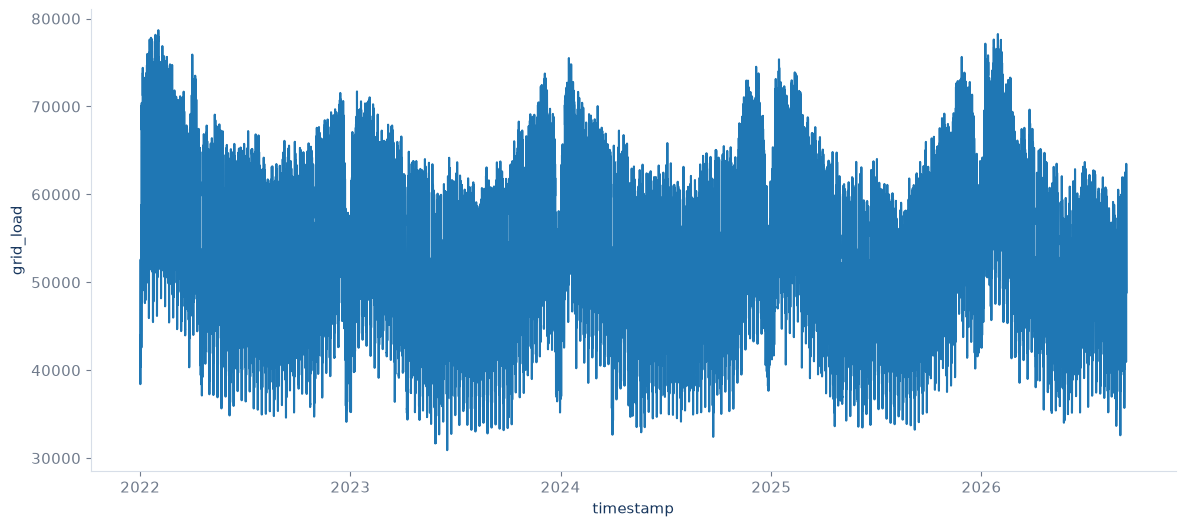

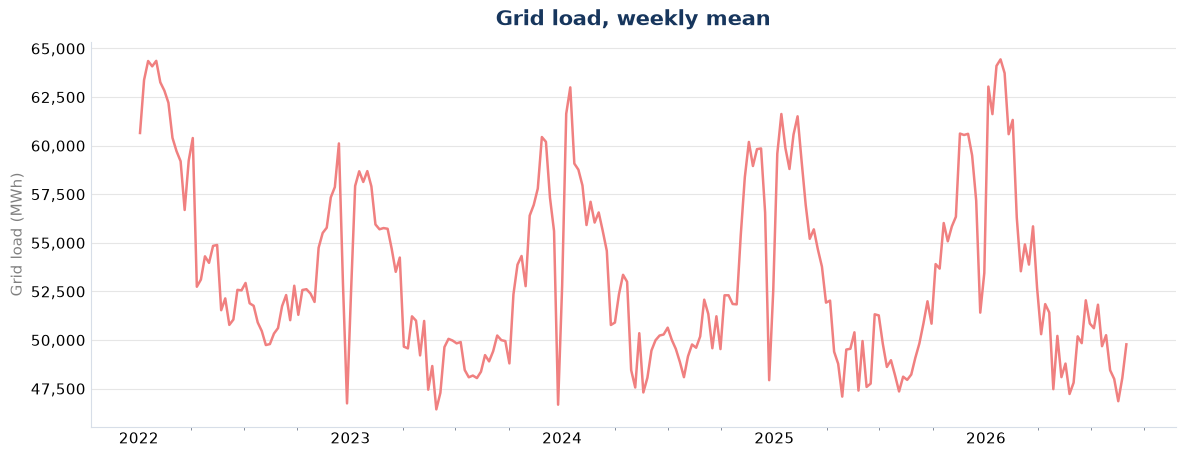

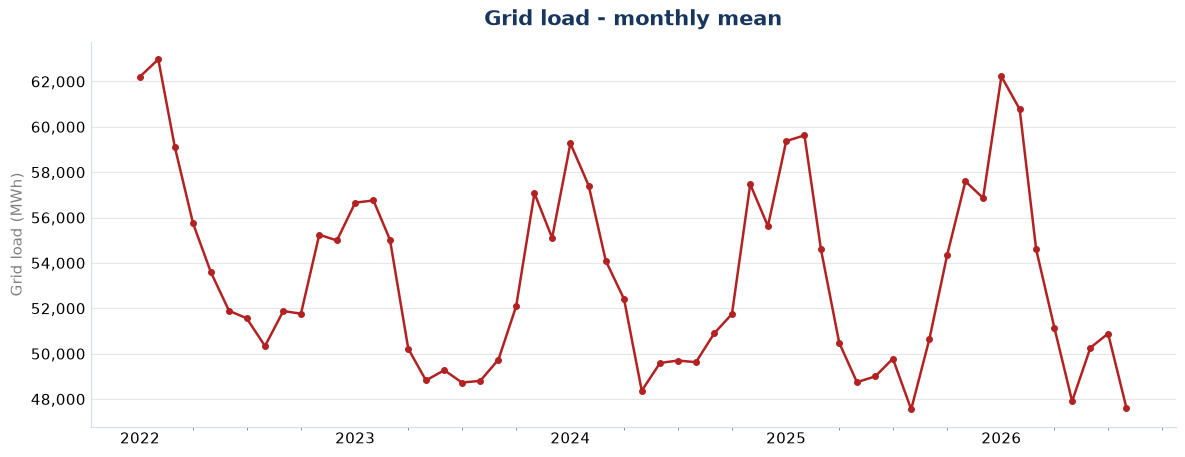

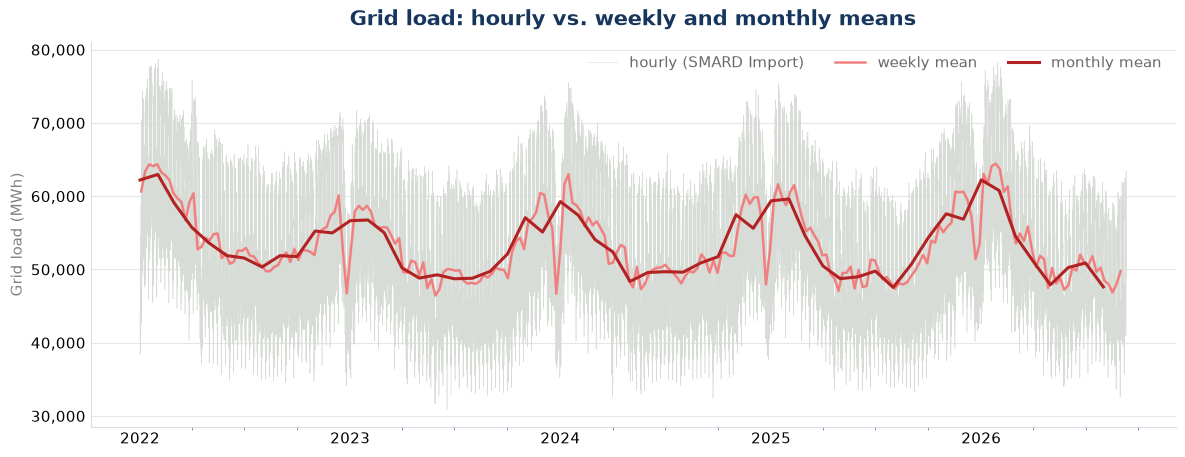

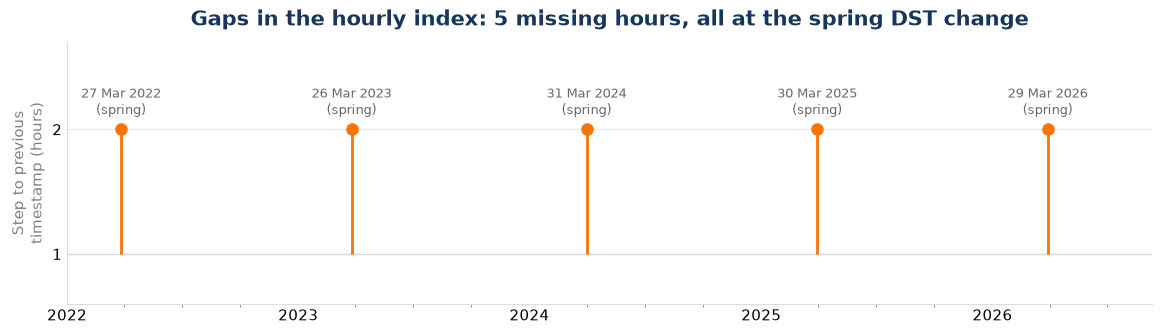

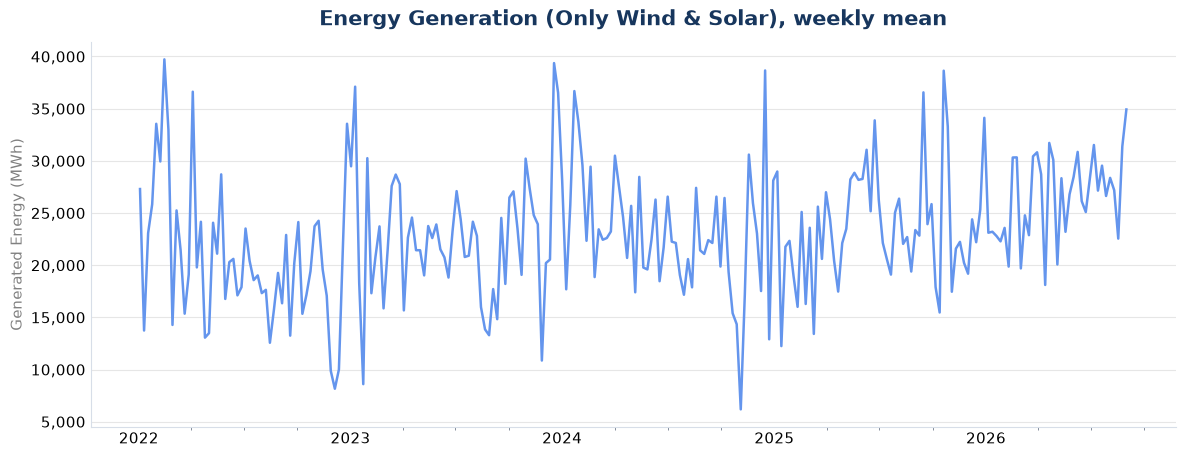

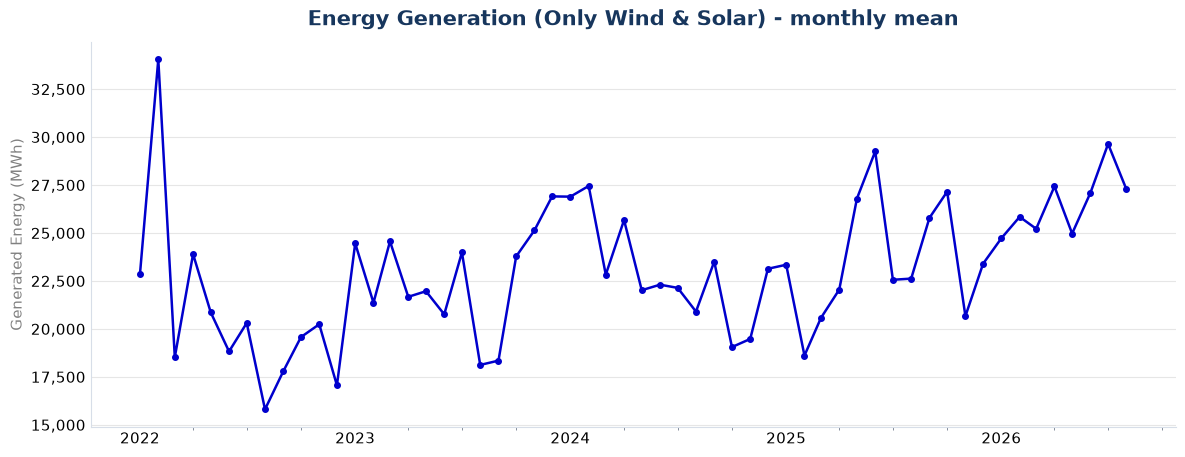

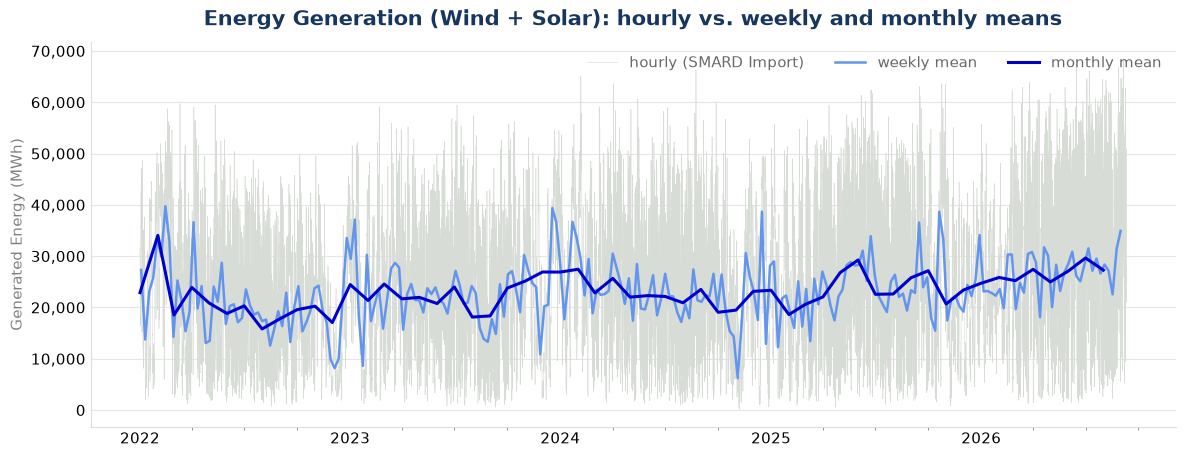

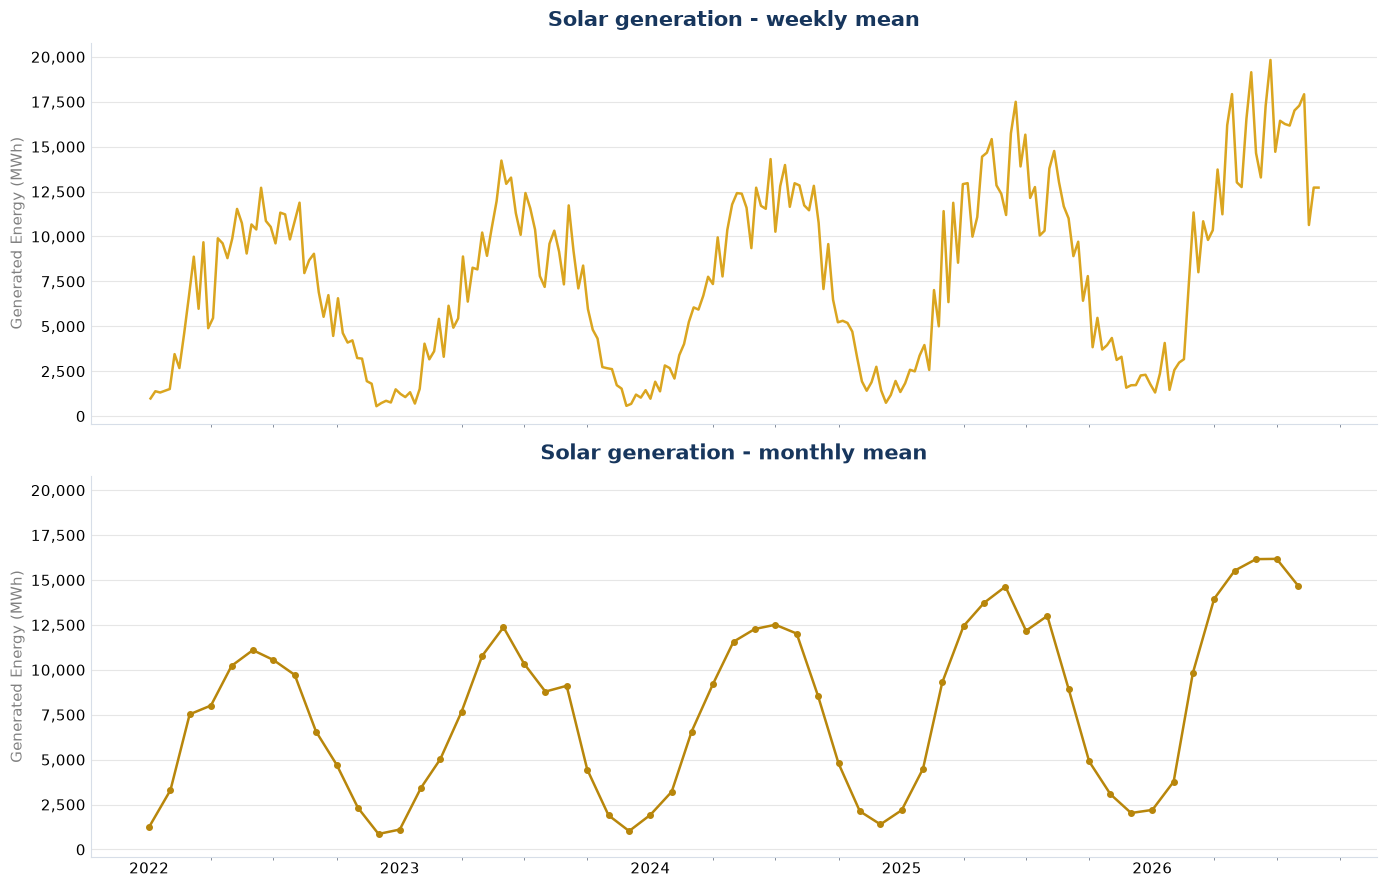

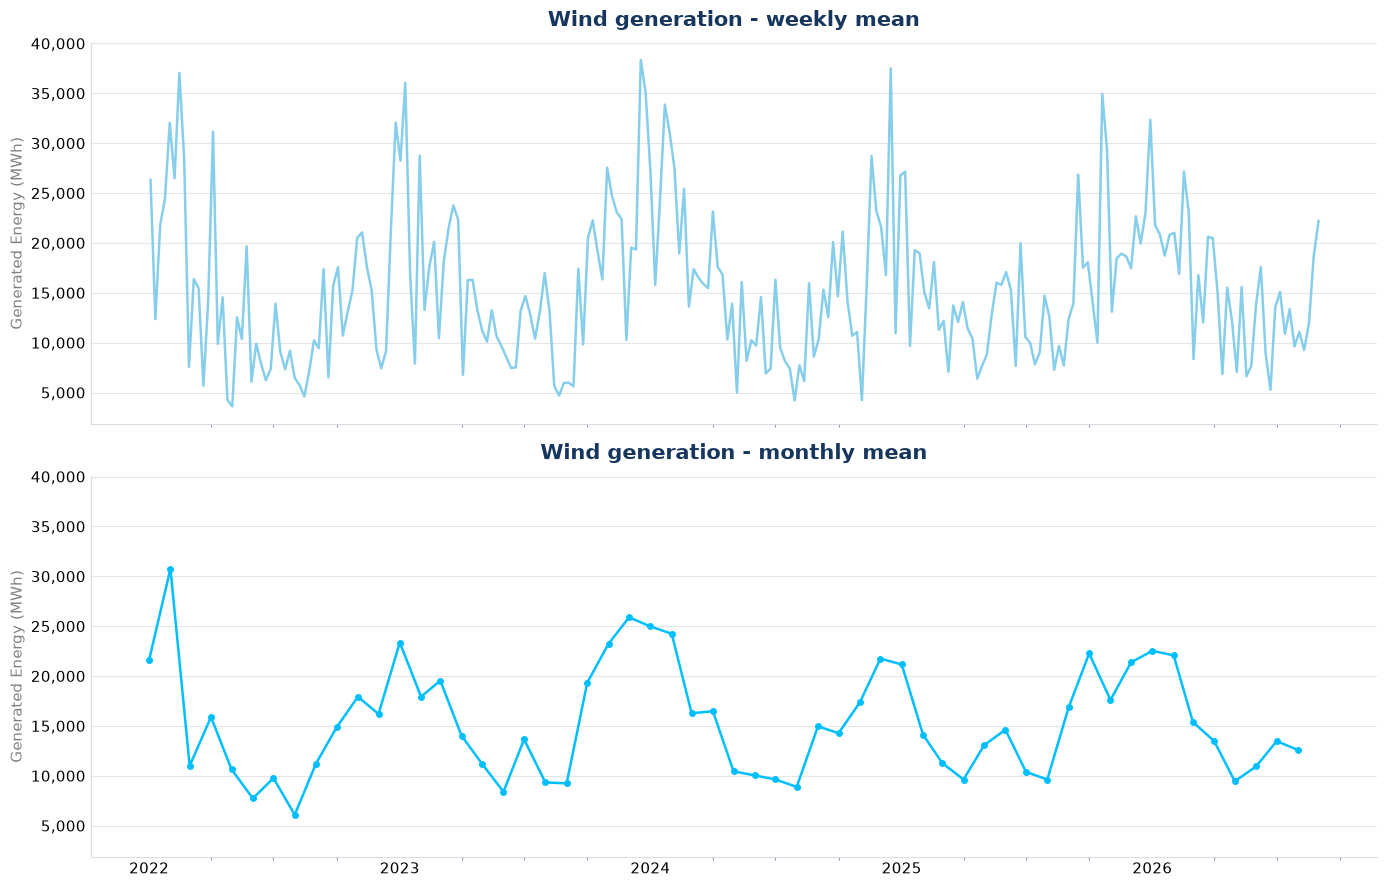

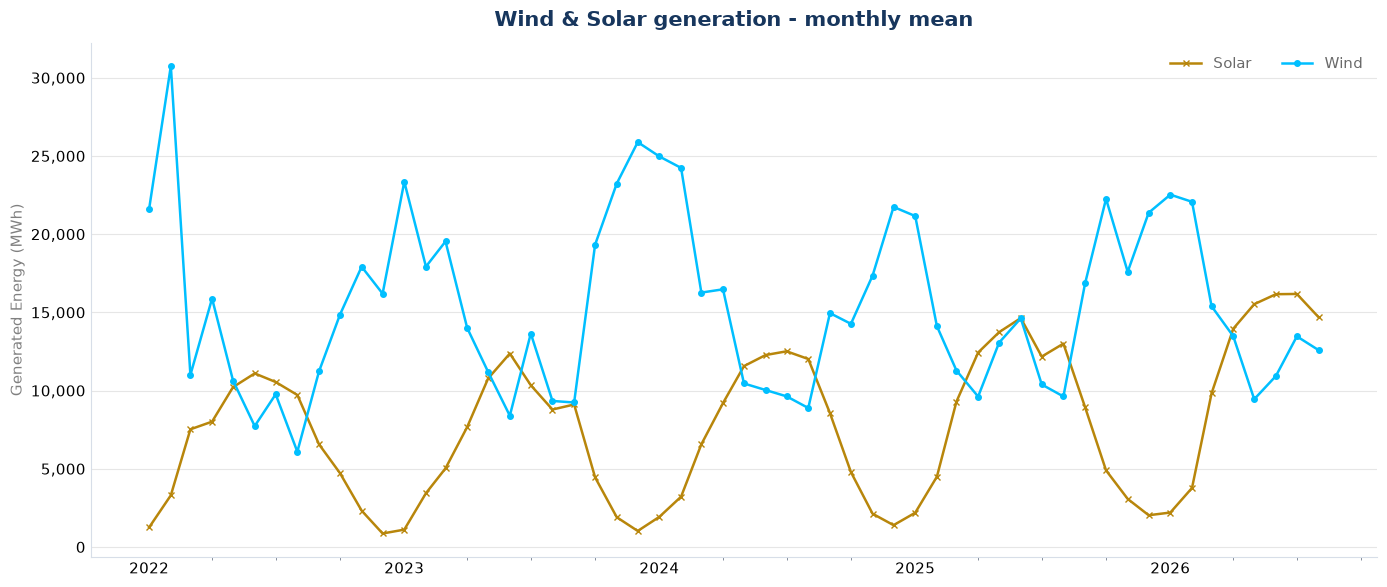

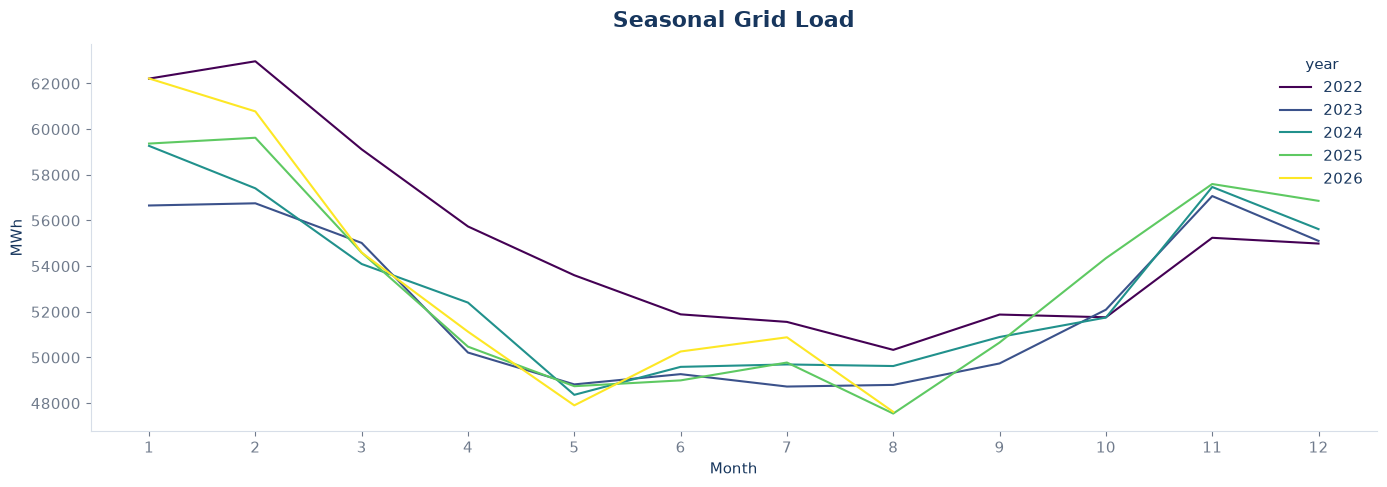

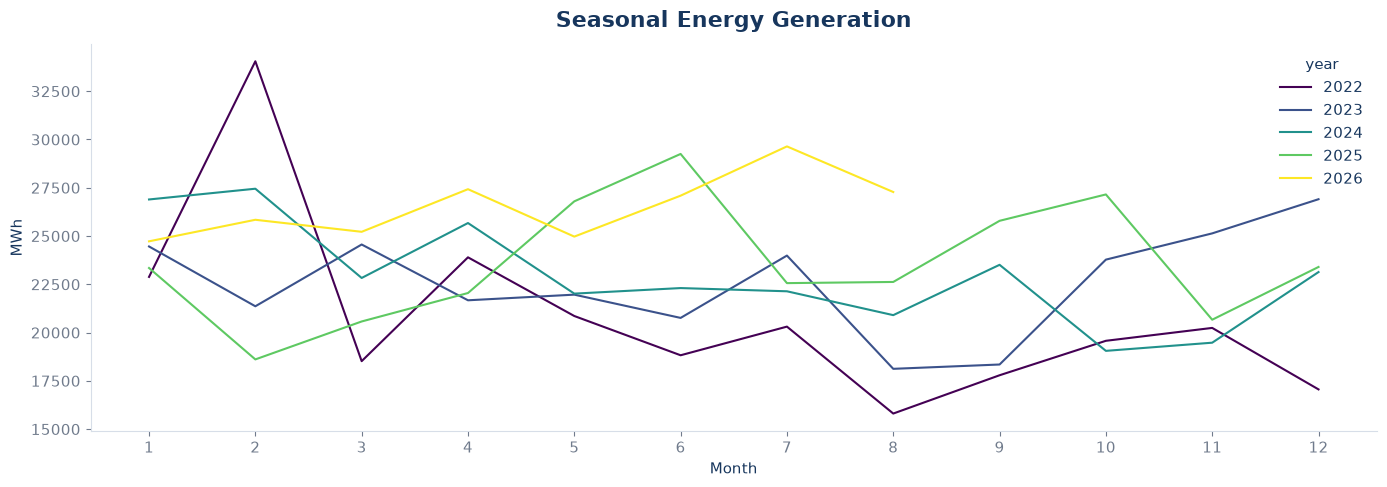

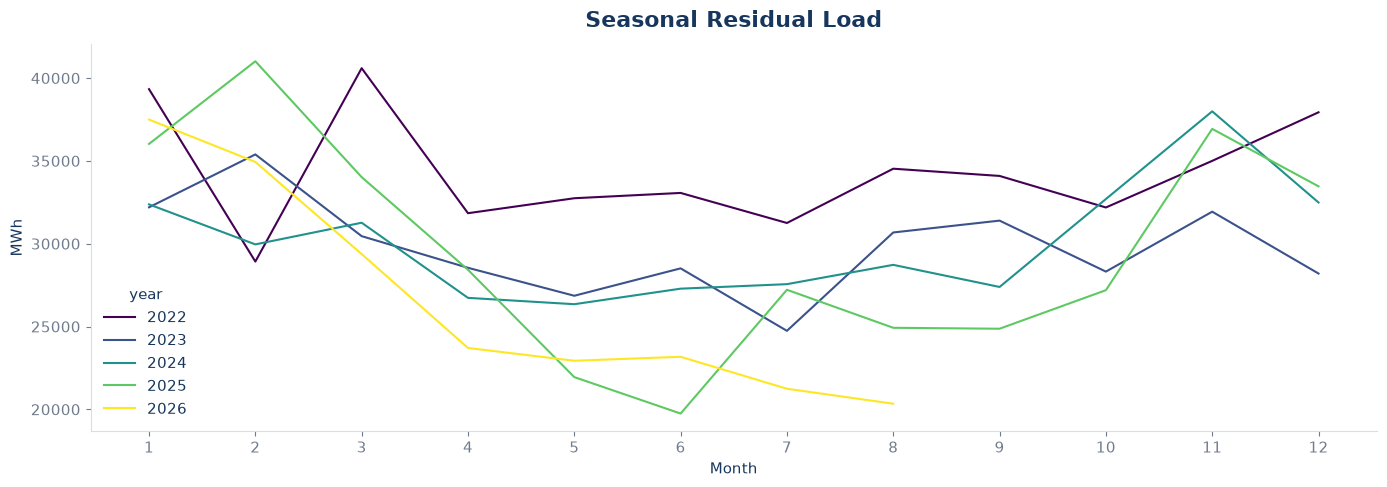

In [15]:
import nbformat

with open("EDA-robert.ipynb", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

for cell in nb.cells:
    if (
        cell.cell_type == "code"
    ):
        exec(cell.source, globals())

54
5 SMARD series | hour | 2019-01-01 to 2026-09-10
Cache: C:\Users\Robert\Coding\neueFische_Data-Science\grid-stress\data\smard_hourly_2019_2026-09-10.csv
   1225  Wind Offshore            ok
   4067  Wind Onshore             ok
   4068  Solar                    ok
    410  Grid Load                ok
   4359  Residual Load (SMARD)    ok

All endpoints reachable.
Wind Offshore              67415 values
Wind Onshore               67415 values
Solar                      67415 values
Grid Load                  67415 values
Residual Load (SMARD)      67415 values
Saved: C:\Users\Robert\Coding\neueFische_Data-Science\grid-stress\data\smard_hourly_2019_2026-09-10.csv

Downloaded table: (67415, 5)
Rows × columns: 67,415 × 5
First timestamp: 2018-12-31 23:00:00+00:00
Last timestamp:  2026-09-09 21:00:00+00:00

First observations


,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load (SMARD)
timestamp_utc,,,,,
2018-12-31 23:00:00+00:00,3134.00,20314.25,0.0,43273.75,19825.50
2019-01-01 00:00:00+00:00,2868.25,22297.25,0.0,41631.25,16465.75
2019-01-01 01:00:00+00:00,2460.25,23168.50,0.0,40085.00,14456.25
2019-01-01 02:00:00+00:00,2696.50,24471.75,0.0,39269.75,12101.50
2019-01-01 03:00:00+00:00,2578.00,26320.50,0.0,39032.75,10134.25
2019-01-01 04:00:00+00:00,2377.25,27898.00,0.0,38570.50,8295.25



Last observations


,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load (SMARD)
timestamp_utc,,,,,
2026-09-09 16:00:00+00:00,4858.22,18750.40,5470.77,60160.33,31080.95
2026-09-09 17:00:00+00:00,4565.06,16645.74,821.53,59391.73,37359.40
2026-09-09 18:00:00+00:00,4626.21,16411.40,0.15,57694.66,36656.91
2026-09-09 19:00:00+00:00,4395.91,17227.84,0.00,54371.73,32747.98
2026-09-09 20:00:00+00:00,4210.74,18383.80,0.00,51569.83,28975.29
2026-09-09 21:00:00+00:00,4231.90,19239.14,0.00,48852.16,25381.12



A few observations from the middle


,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load (SMARD)
timestamp_utc,,,,,
2018-12-31 23:00:00+00:00,3134.00,20314.25,0.00,43273.75,19825.50
2020-07-15 17:00:00+00:00,74.00,2664.50,3243.50,58584.00,52602.00
2022-01-28 12:00:00+00:00,2321.50,20124.00,9590.25,72842.50,40806.75
2023-08-13 07:00:00+00:00,3436.25,2828.75,16954.50,42210.75,18991.25
2025-02-25 02:00:00+00:00,3122.00,11829.50,6.00,46542.79,31585.29
2026-09-09 21:00:00+00:00,4231.90,19239.14,0.00,48852.16,25381.12



Quick column check


,dtype,missing,min,median,max
Wind Offshore,float64,0,0.00,2658.00,8448.34
Wind Onshore,float64,0,46.50,9246.25,48499.50
Solar,float64,0,0.00,237.50,58055.53
Grid Load,float64,0,30902.75,54456.25,81319.50
Residual Load (SMARD),float64,0,-15561.59,33914.25,74638.75


Duplicate timestamps removed: 0
Negative primitive values set to NaN: {'Grid Load': 0, 'Wind Onshore': 0, 'Wind Offshore': 0, 'Solar': 0}

Missing values after alignment:
Wind Offshore            0
Wind Onshore             0
Solar                    0
Grid Load                0
Residual Load (SMARD)    0
dtype: int64

Median |SMARD residual − identity|: 0.00
P95    |SMARD residual − identity|: 0.01


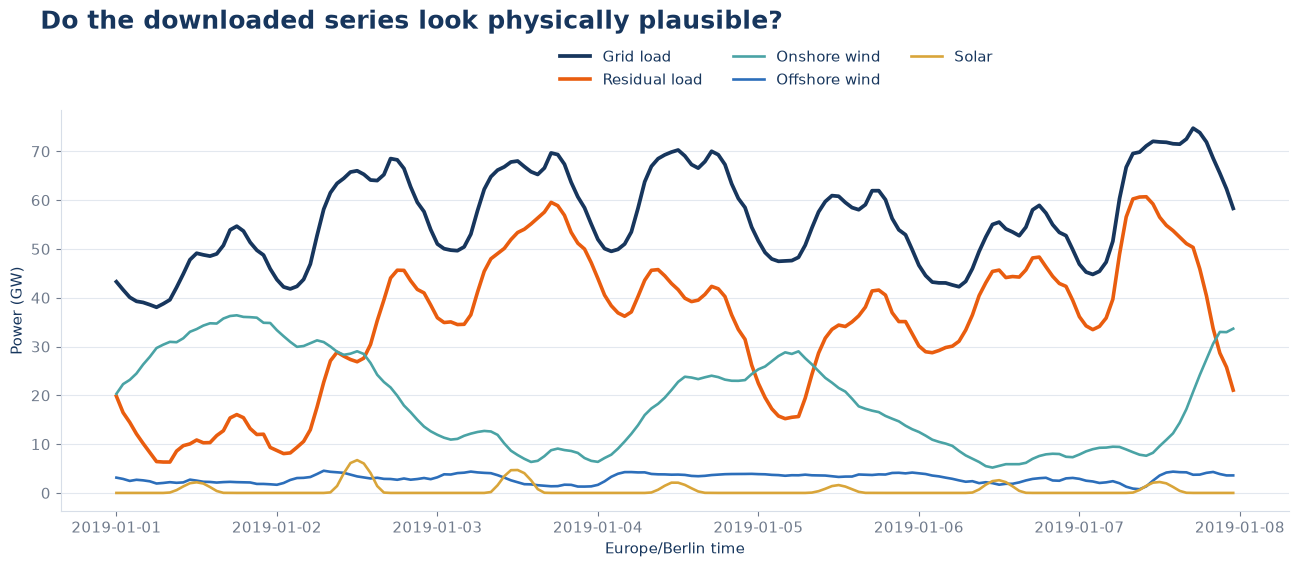

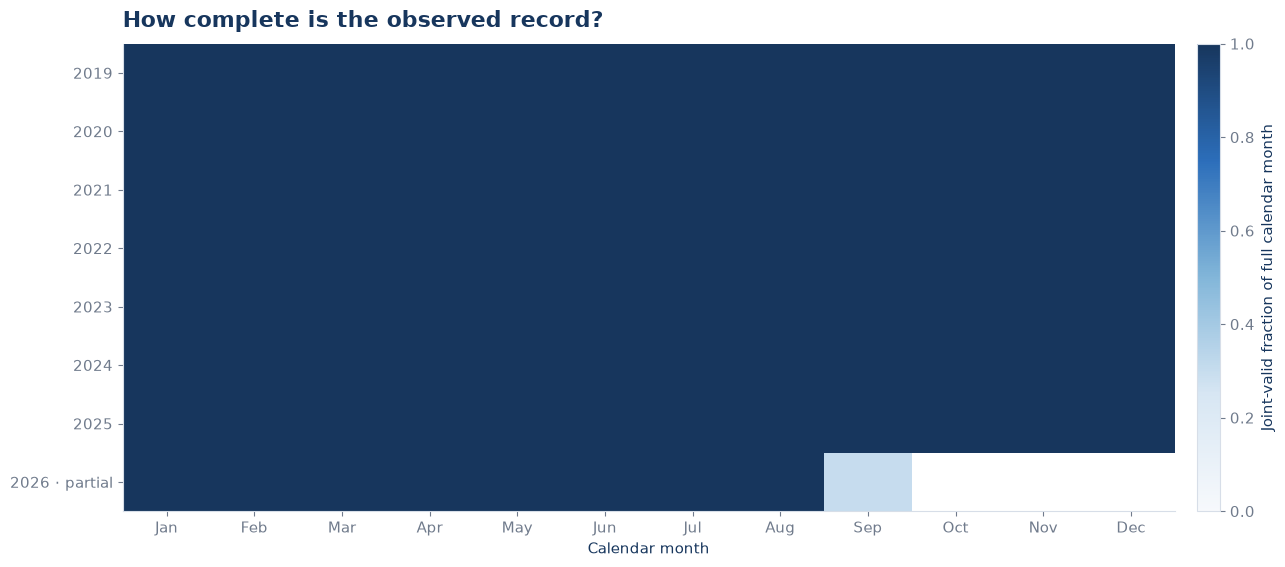

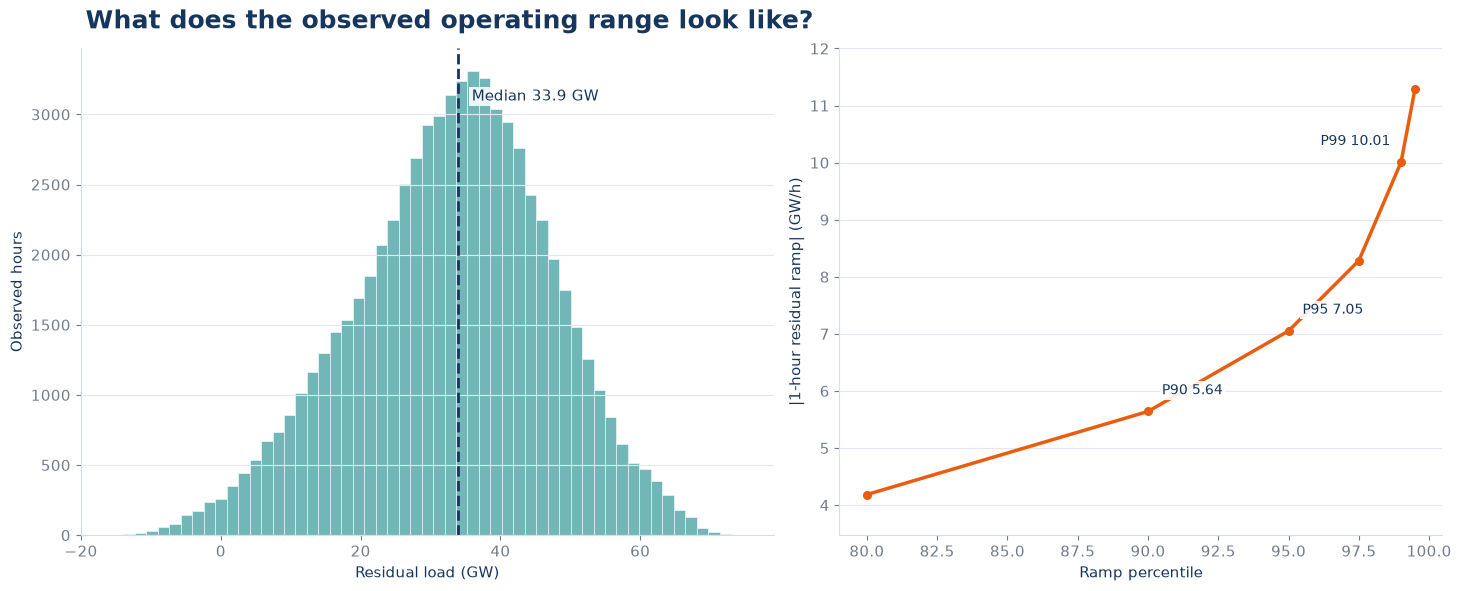

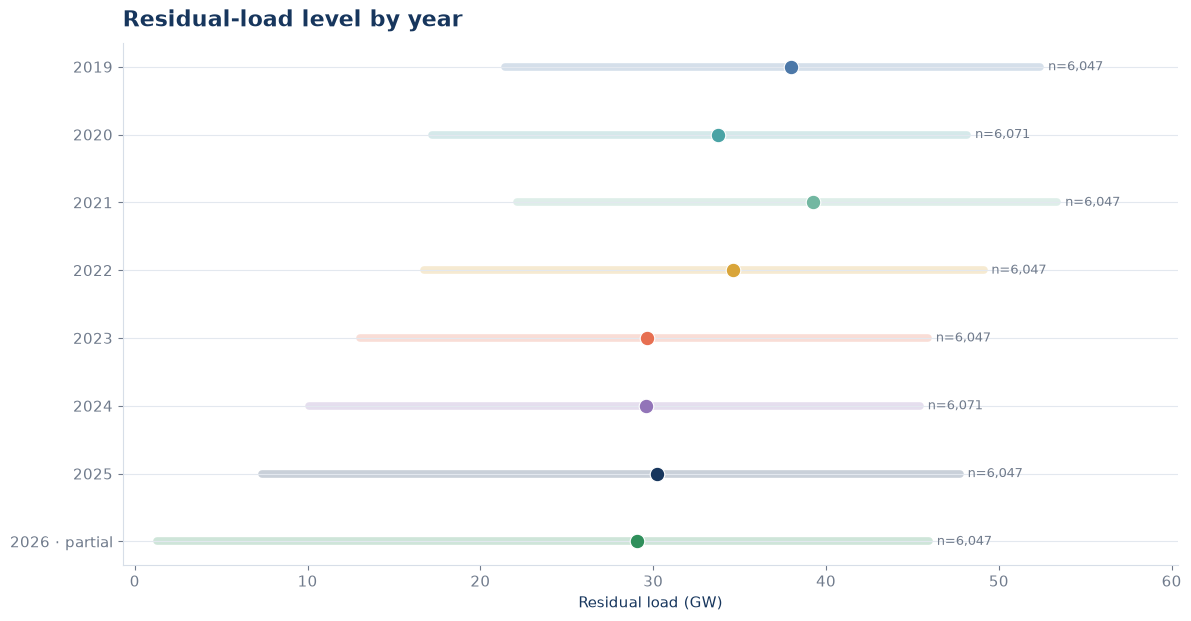

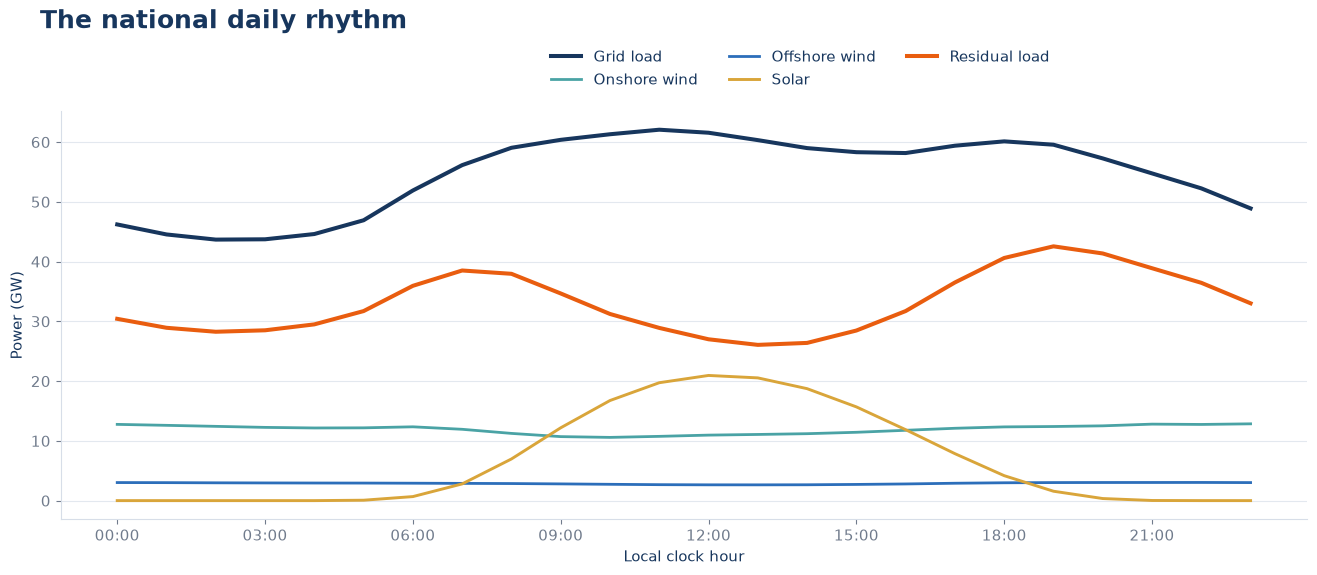

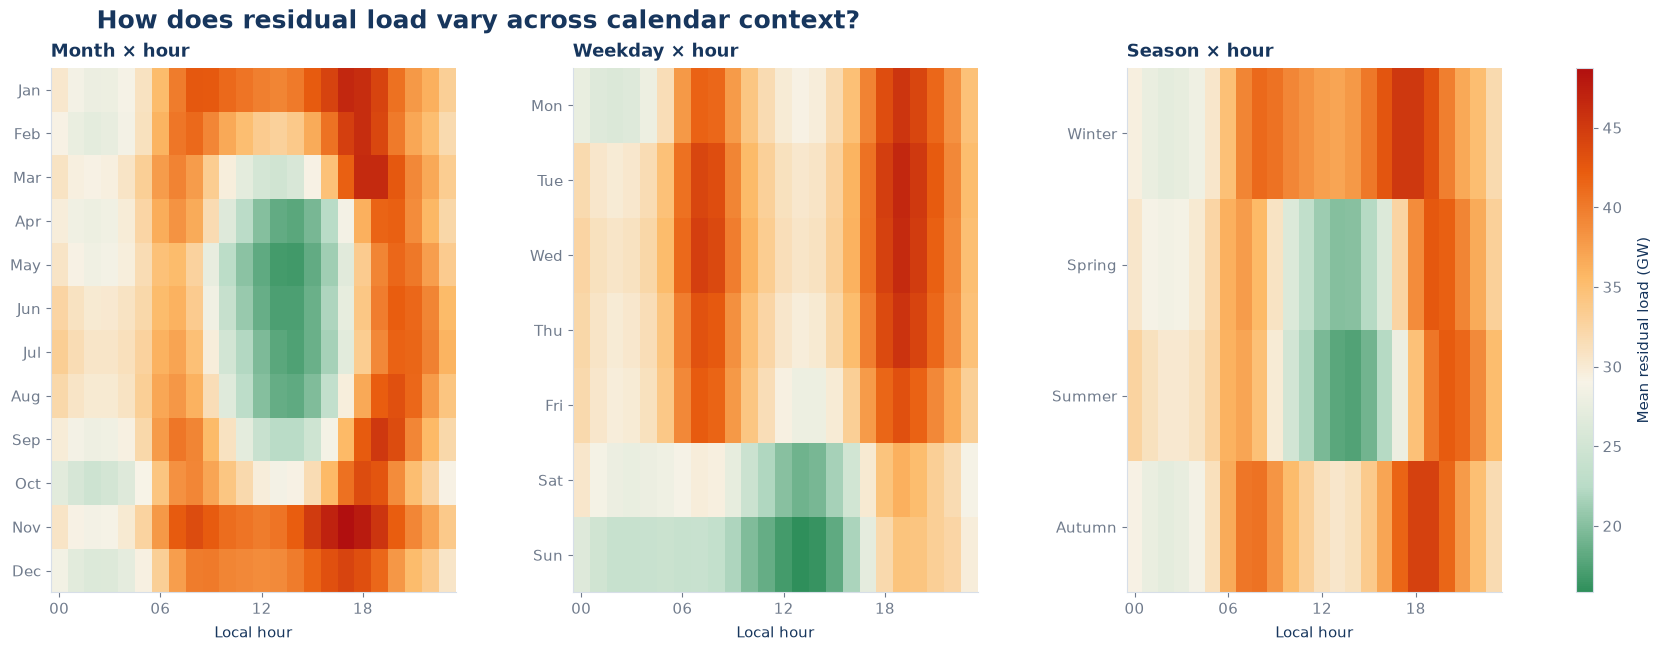

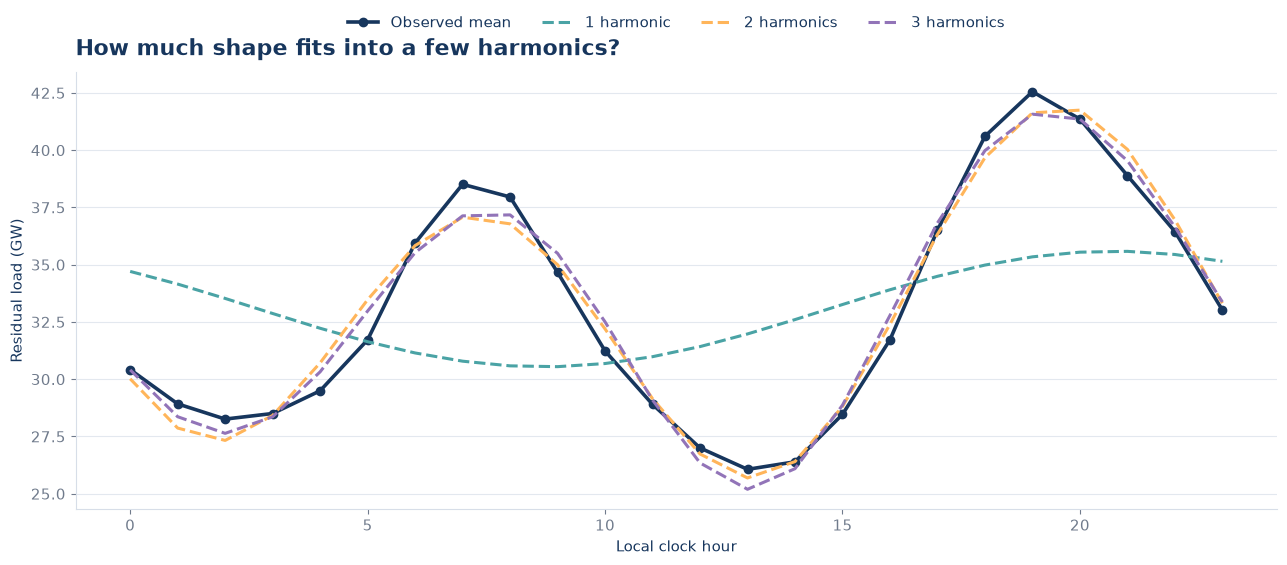

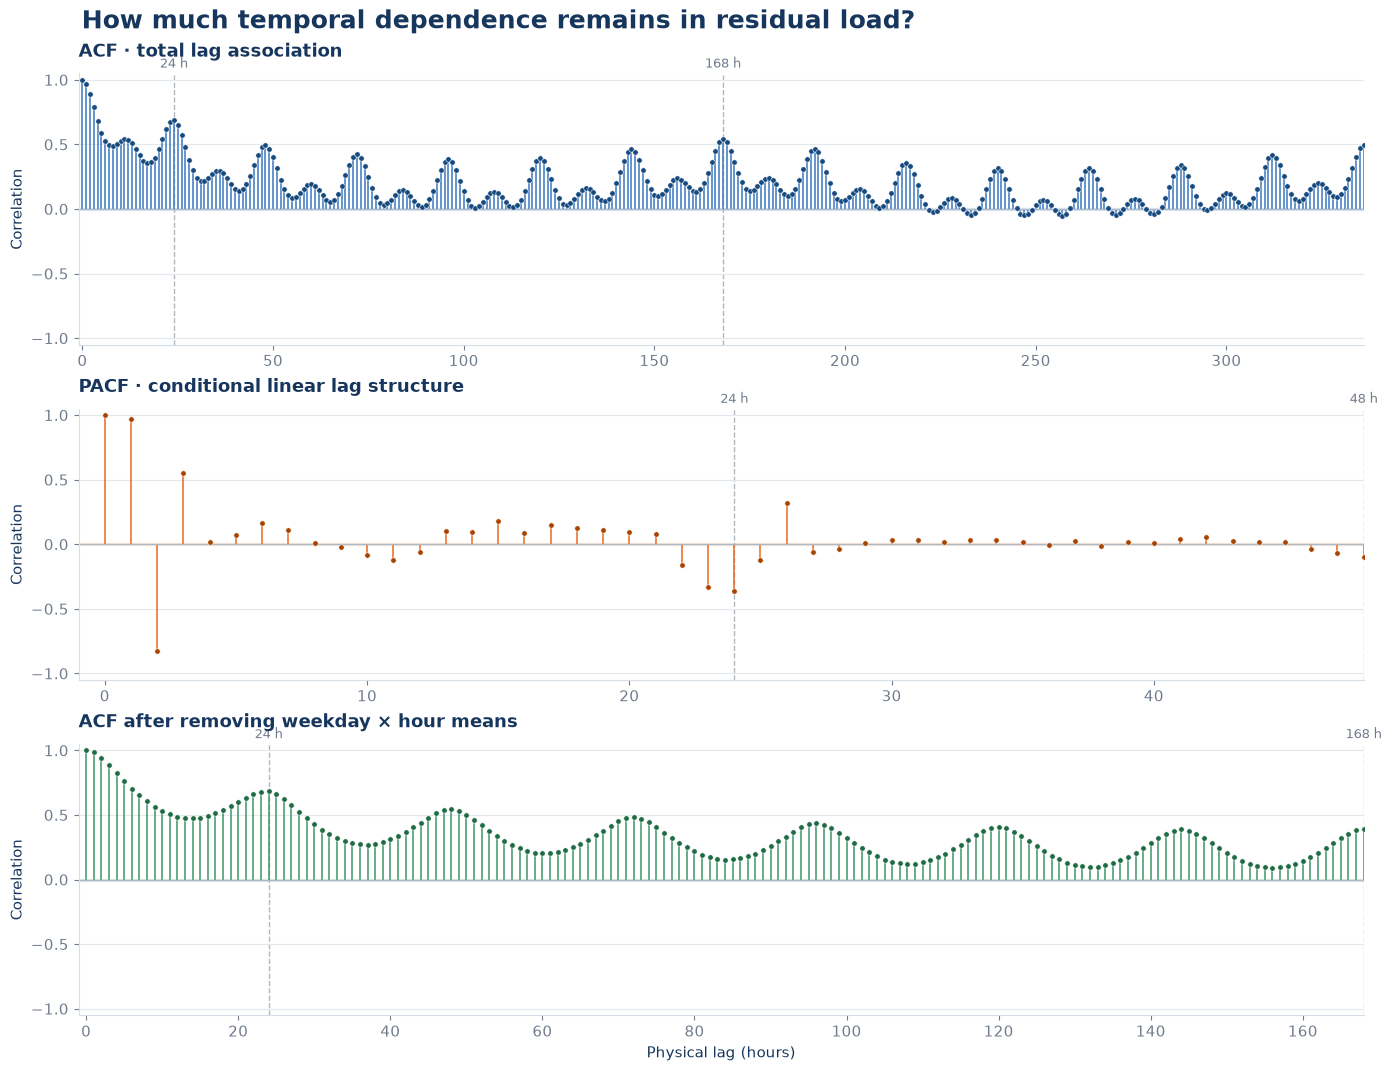

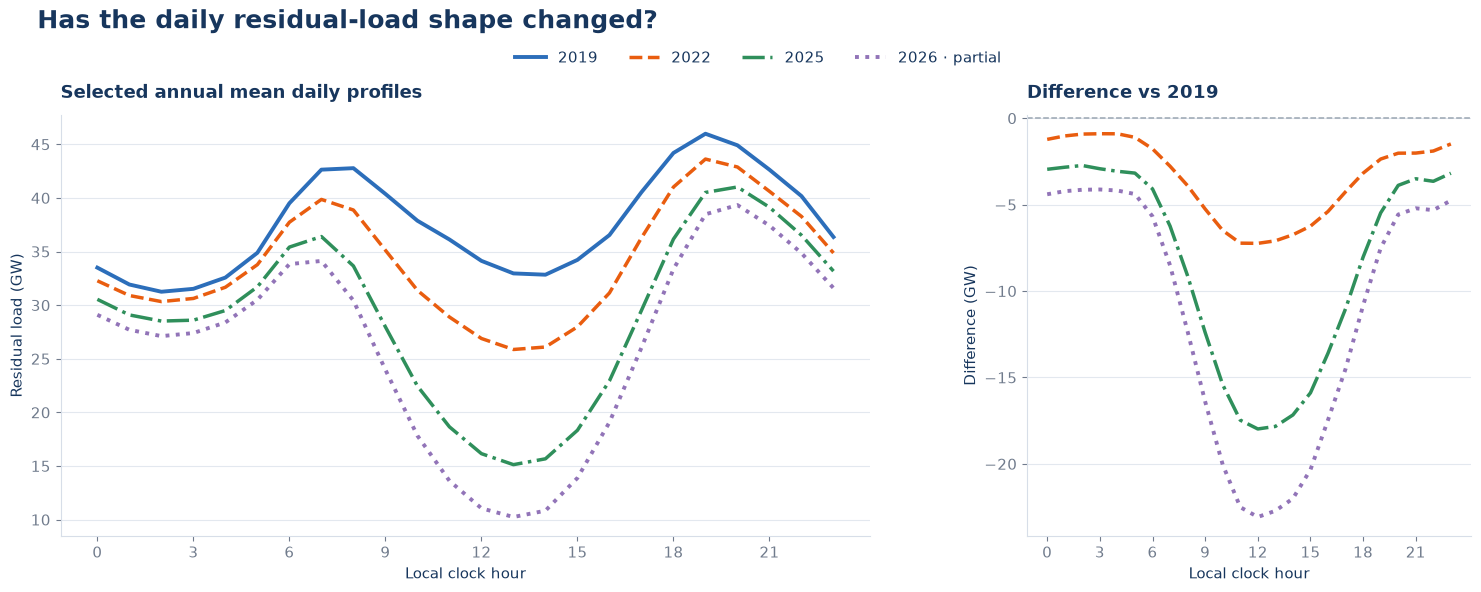

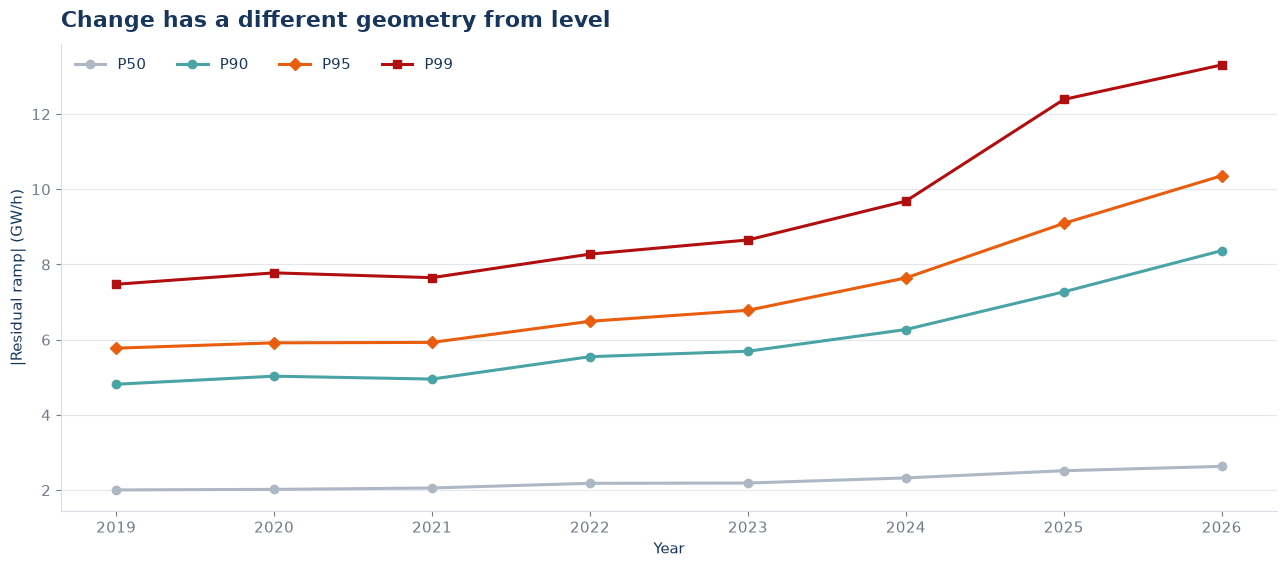

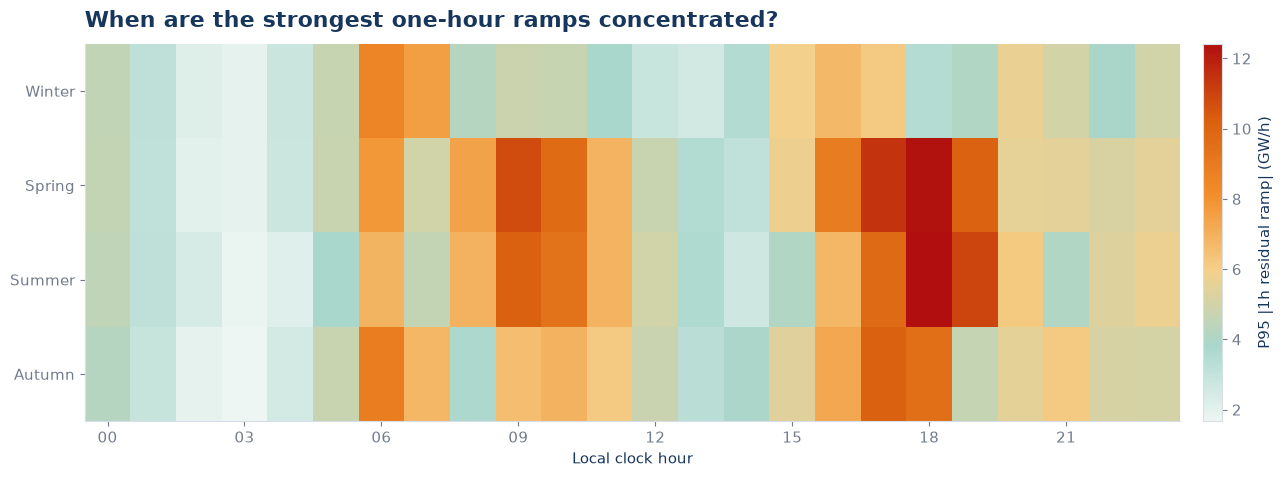

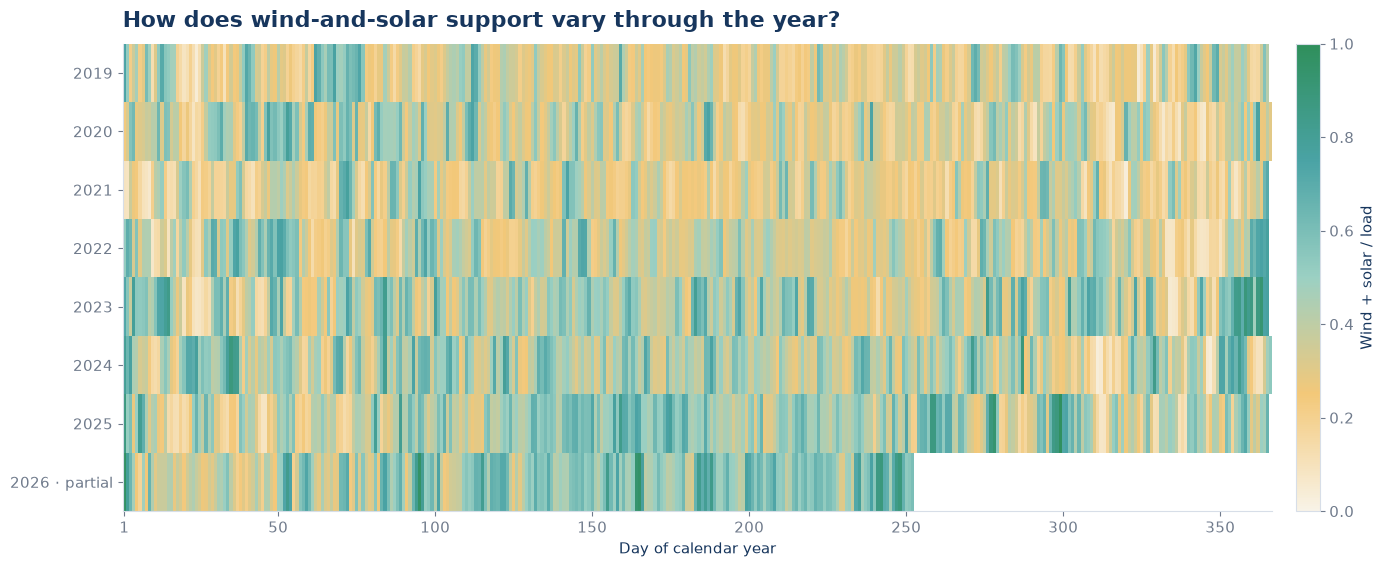

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


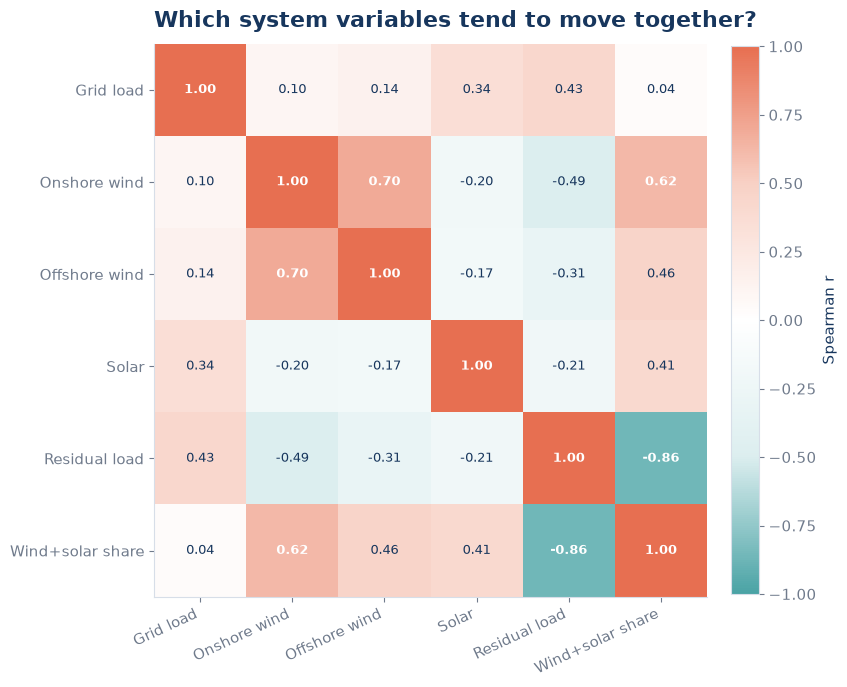

In [14]:
with open("Hari_GridStress_API_EDA_Data_Visualisation.ipynb", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

cell_count = len(nb.cells)

print(cell_count)

for cell in nb.cells:
    if (
        cell.cell_type == "code"
    ):
        exec(cell.source, globals())

pandas 3.0.5 · numpy 2.5.3 · seaborn 0.13.2
reading c:\Users\Robert\Coding\neueFische_Data-Science\grid-stress\data\smard.csv
as read from disk — note the comma decimals and the string dtypes:


,timestamp,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load,Forecast Wind + Solar,Forecast Grid load,Forecast Residual Load
0,2022-01-01 00:00,"5975,5","25570,25","2,0","43915,5","12367,75","31530,75","41989,5","10458,75"
1,2022-01-01 01:00,"5775,25","24318,25","2,0","41535,75","11440,25","30462,5","40105,5","9643,0"
2,2022-01-01 02:00,"5548,0","23169,5","2,0","40480,75","11761,25","29055,25","38784,0","9728,75"


,dtype
timestamp,str
Wind Offshore,str
Wind Onshore,str
Solar,str
Grid Load,str
Residual Load,str
Forecast Wind + Solar,str
Forecast Grid load,str
Forecast Residual Load,str


shape           : 41,107 rows x 8 columns
index           : 2022-01-01 00:00:00  ->  2026-09-09 23:00:00
index monotonic : True, unique: True


,dtype
wind_off,float64
wind_on,float64
solar,float64
grid_load,float64
residual_load,float64
fc_gen_wind_solar,float64
fc_grid_load,float64
fc_res,float64


...

,rows_in_file,rows_labelled_02h,true_local_hours
autumn switch date,,,
2022-10-30,24,1,25
2023-10-29,24,1,25
2024-10-27,24,1,25
2025-10-26,24,1,25


duplicate timestamps: 0


,n_missing,share_%
wind_off,0,0.0
wind_on,0,0.0
solar,0,0.0
grid_load,0,0.0
residual_load,0,0.0
fc_gen_wind_solar,0,0.0
fc_grid_load,0,0.0
fc_res,0,0.0


solar max 58,055.5 MWh -> tolerance 290.3 MWh
night hours defined as [22, 23, 0, 1, 2, 3]

wind_off < 0                                0 violations
wind_on < 0                                 0 violations
solar < 0                                   0 violations
grid_load <= 0                              0 violations
night solar > 290.3 MWh                     0 violations

night solar: max 146.98 MWh, 402 of 10,273 night hours are exactly zero


,count,mean,std,min,50%,95%,99%,max,max_abs,n_above_0.5_MWh
actual,41107.0,0.0011,0.0031,0.0,0.0,0.01,0.01,0.02,0.02,0
forecast,41107.0,0.0004,0.0021,0.0,0.0,0.00,0.01,0.01,0.01,0


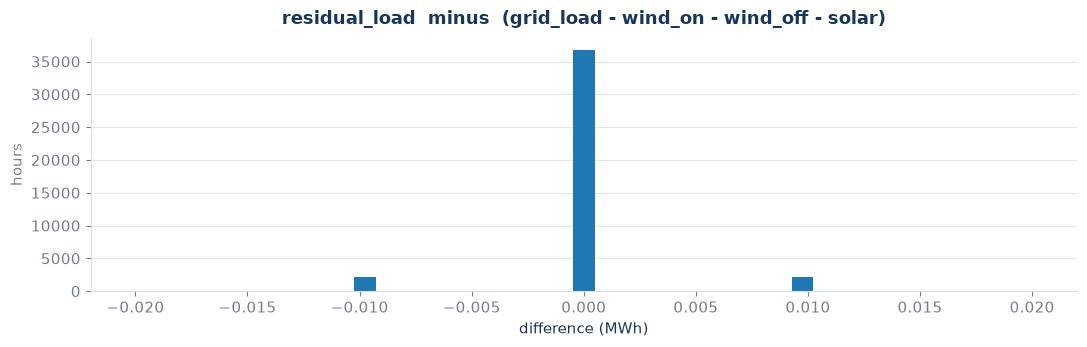

244 complete weekly bins, every one opening Monday 00:00
excluded first bin 2021-12-27/2022-01-02 opens 2022-01-01, a Saturday -- the record starts mid-week, which is why that bin is dropped rather than trusted
the week bin 2021-12-27/2022-01-02
  period_mean    labels it 2021-12-27 (Monday) -- period START
  resample('W')  labels it 2022-01-02 (Sunday) -- RIGHT EDGE
W: period_mean keeps 244, resample produces 246, agreeing on all 244 shared periods
   dropped 2021-12-27/2022-01-02:     46,910 MW   vs neighbour 2022-01-03/2022-01-09:     60,652 MW   (-22.7%)
   dropped 2026-09-07/2026-09-13:     53,588 MW   vs neighbour 2026-08-31/2026-09-06:     49,778 MW   (+7.7%)

M: period_mean keeps 56, resample produces 57, agreeing on all 56 shared periods
   dropped 2026-09:     50,967 MW   vs neighbour 2026-08:     47,619 MW   (+7.0%)

first three months:


,hourly_mean,avg_mw,mwh_per_day,naive,days,hours,naive_err_%,complete
timestamp,,,,,,,,
2022-01-01,62213.82,62213.82,1493131.58,62213.82,31,744,0.00,True
2022-02-01,62973.06,62973.06,1511353.54,62973.06,28,672,0.00,True
2022-03-01,59116.10,59116.10,1416879.34,59036.64,31,743,-0.13,True


every month where hours != 24 x days -- the only rows where the naive denominator lies:


,hourly_mean,avg_mw,mwh_per_day,naive,days,hours,naive_err_%,complete
timestamp,,,,,,,,
2022-03-01,59116.10,59116.10,1416879.34,59036.64,31,743,-0.13,True
2023-03-01,55017.46,55017.46,1318644.36,54943.52,31,743,-0.13,True
2024-03-01,54095.02,54095.02,1296535.54,54022.31,31,743,-0.13,True
2025-03-01,54594.34,54594.34,1308503.06,54520.96,31,743,-0.13,True
2026-03-01,54593.98,54593.98,1308494.37,54520.60,31,743,-0.13,True
2026-09-01,50966.85,50966.85,366961.31,15290.05,30,216,-70.00,False


February 2022 vs January 2022, same data, two aggregations:
  raw monthly sum : -8.6 %   (46,287,079 -> 42,317,899 MWh)
  MWh per day     : +1.2 %
  average MW      : +1.2 %


season,winter,spring,summer,autumn
season_year,,,,
2022,1416,2207,2208,2184
2023,2160,2207,2208,2184
2024,2184,2207,2208,2184
2025,2160,2207,2208,2184
2026,2160,2207,2208,216


season_year = year + (month == 12)


,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
wind_off,2902.3,1991.8,0.0,32.3,202.8,1119.0,2629.9,4557.0,6257.5,7278.3,8448.3
wind_on,12444.1,9730.5,46.5,706.3,1515.1,4705.2,9788.5,18025.6,32772.5,40612.2,48499.5
solar,7750.0,11822.7,0.0,0.0,2.5,6.1,312.3,12465.8,34122.9,44887.2,58055.5
grid_load,53336.1,9282.3,30902.8,35542.4,39083.5,45716.3,53380.2,60172.9,68991.9,73321.0,78680.5
residual_load,30239.6,14339.8,-15561.6,-3501.3,5109.9,20636.5,31152.2,40192.1,52918.7,61691.0,70964.0
fc_gen_wind_solar,22974.9,14025.9,320.5,2180.4,4171.6,11069.3,21201.8,32789.9,48334.8,57727.9,75722.2
fc_grid_load,53602.6,8961.5,30544.8,36186.4,39646.8,46300.2,53458.0,60784.2,68094.8,71180.0,75916.2
fc_res,30627.7,14124.9,-29003.2,-3486.7,5395.6,21448.1,31655.6,40559.7,52578.1,60602.4,68032.8


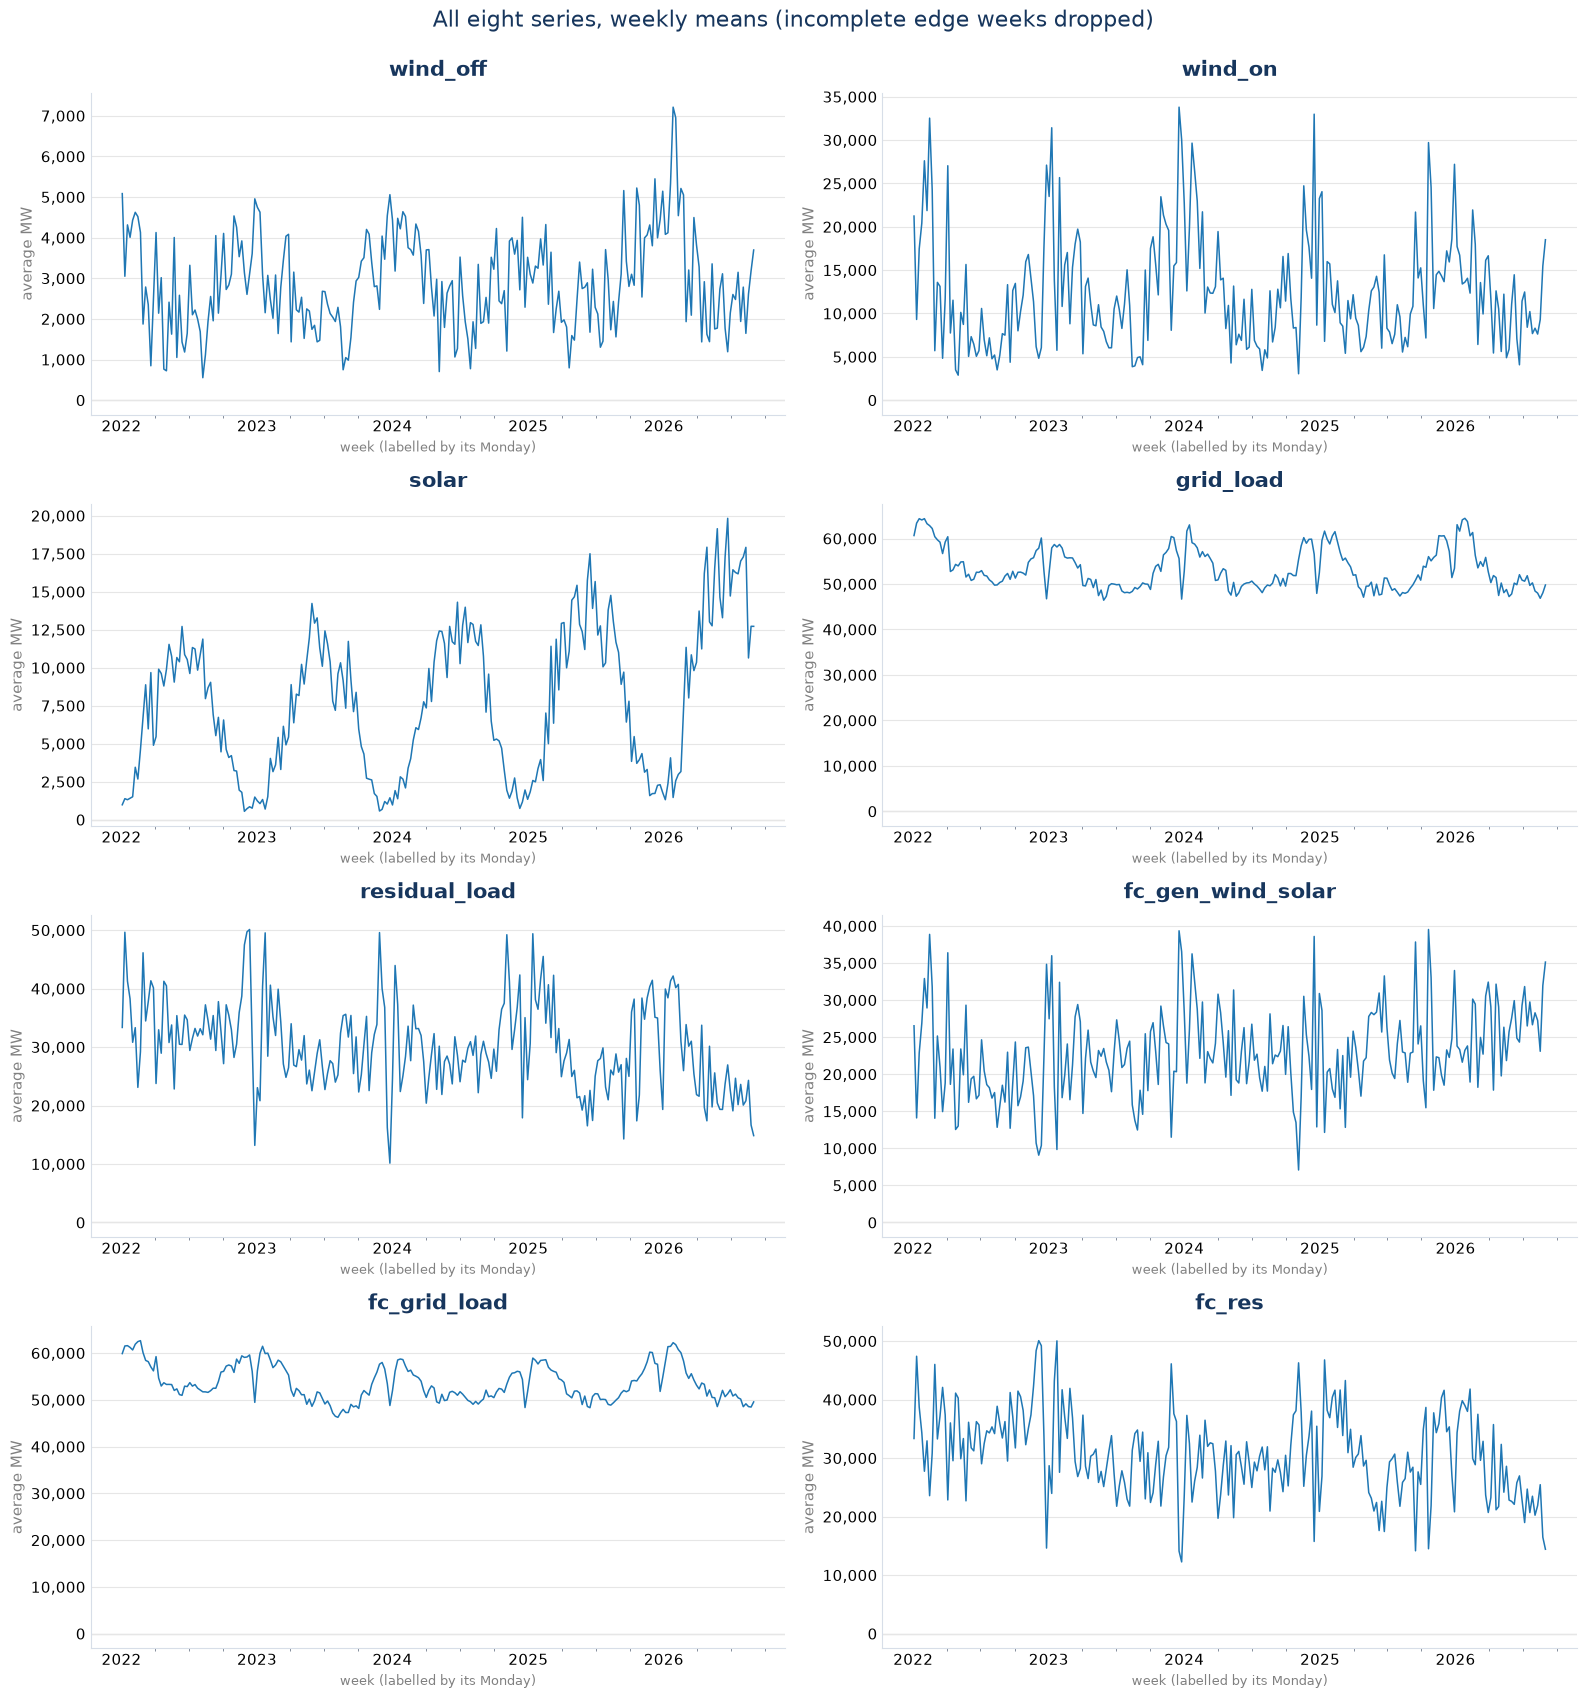

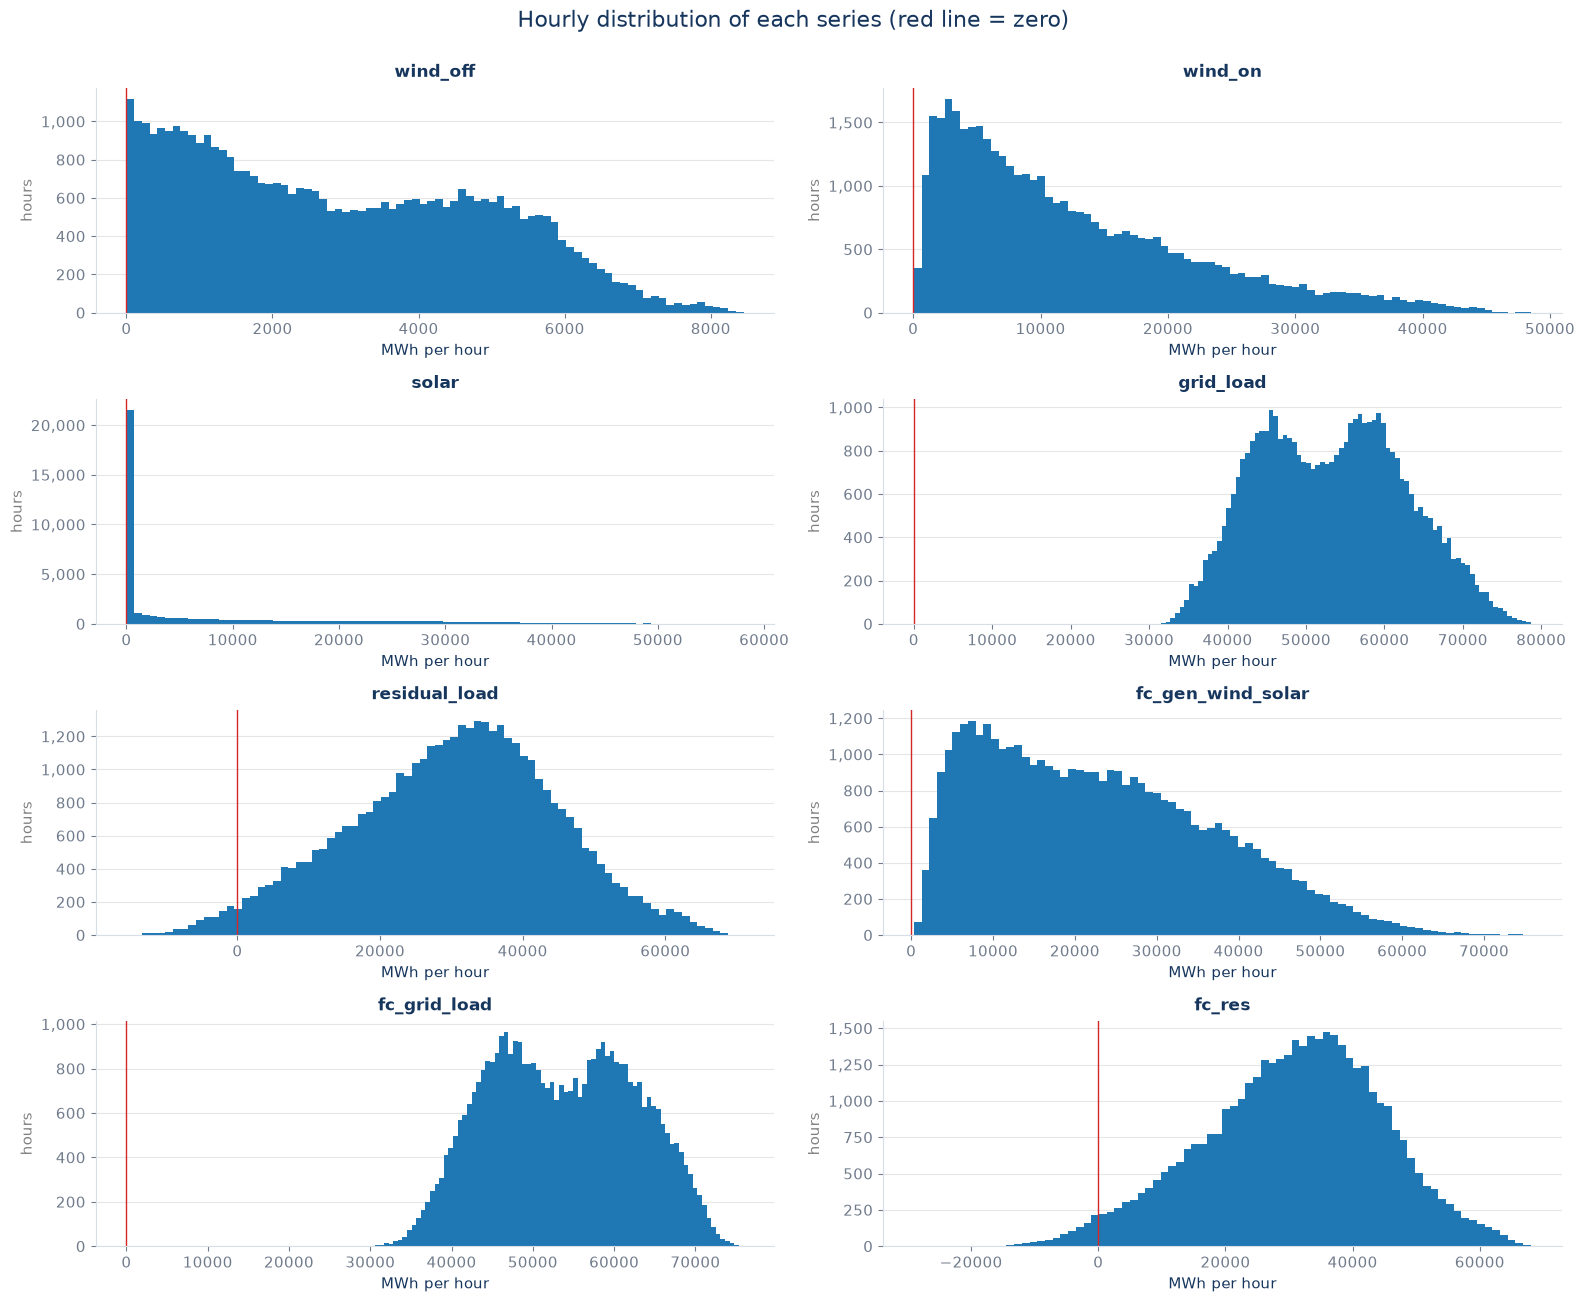

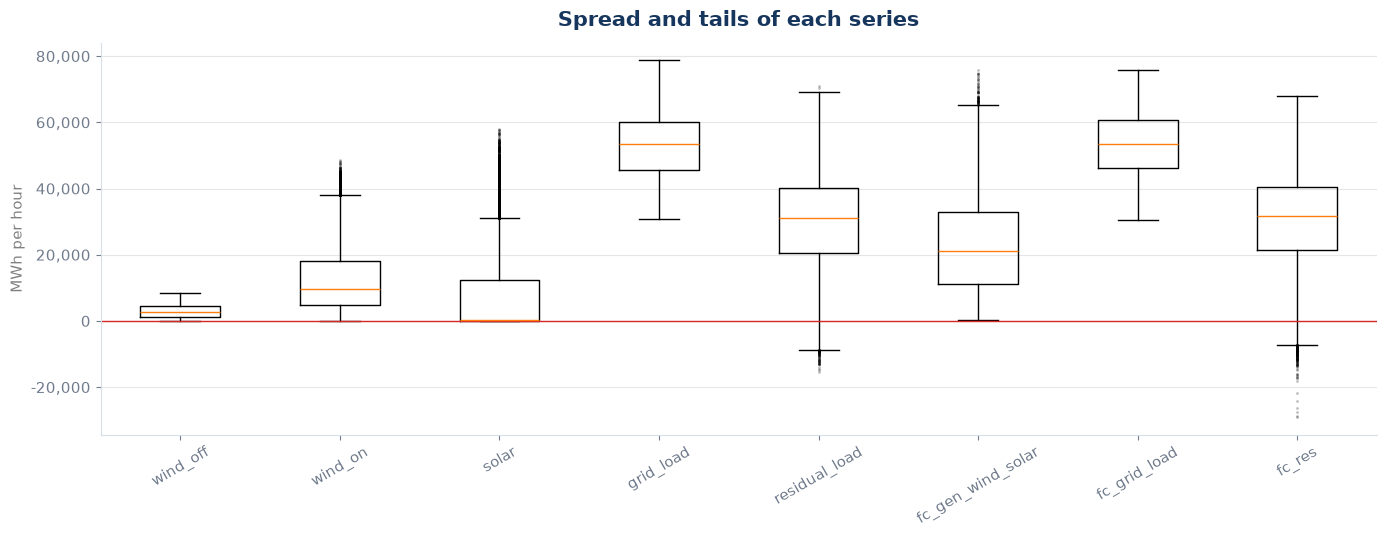

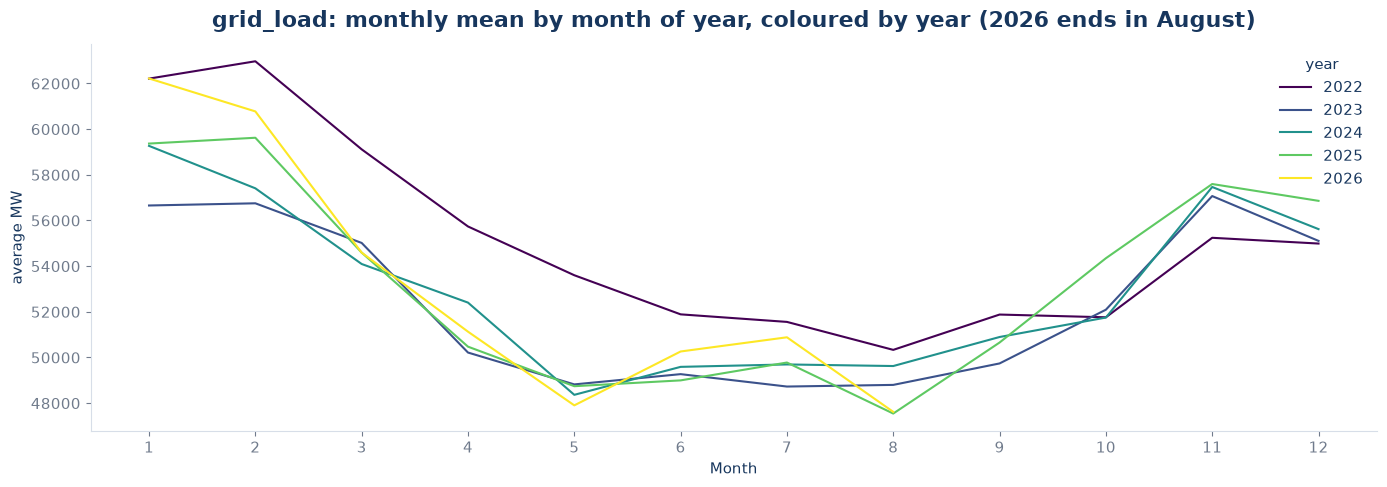

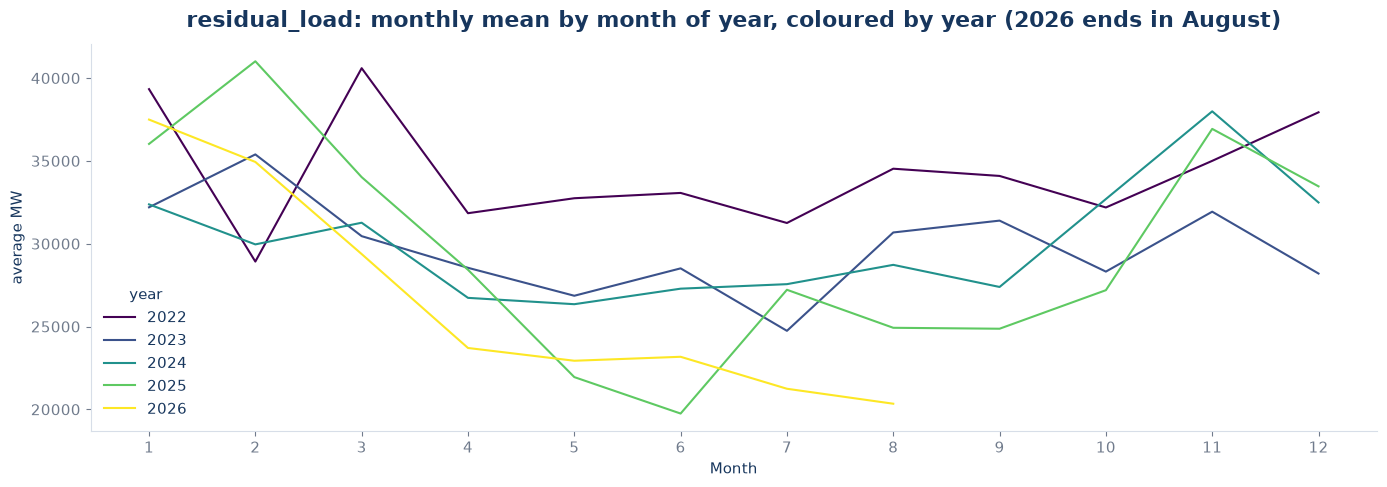

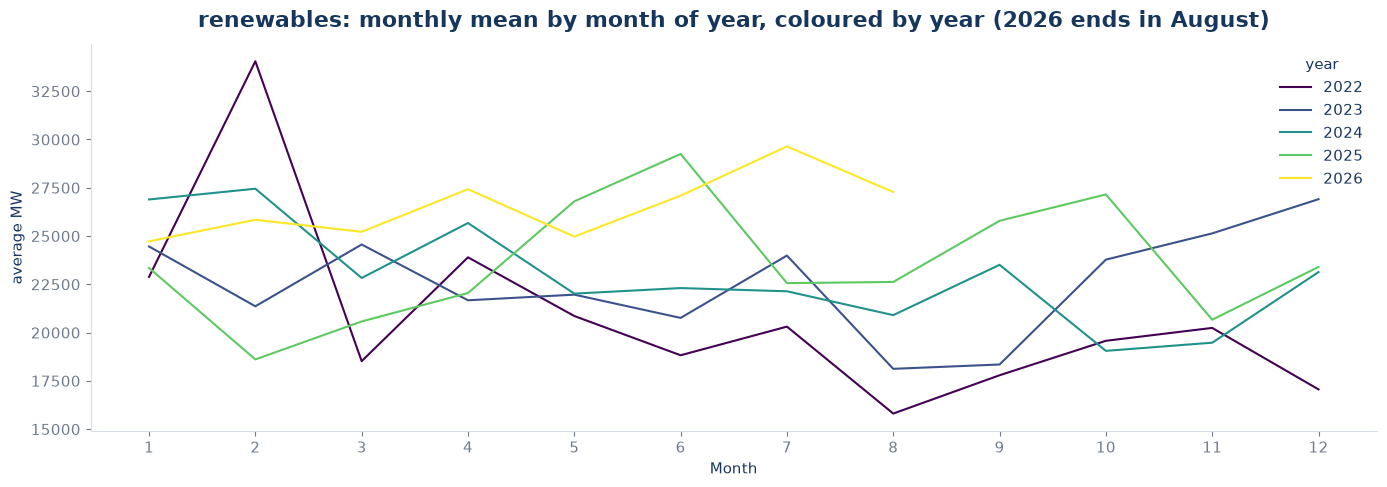

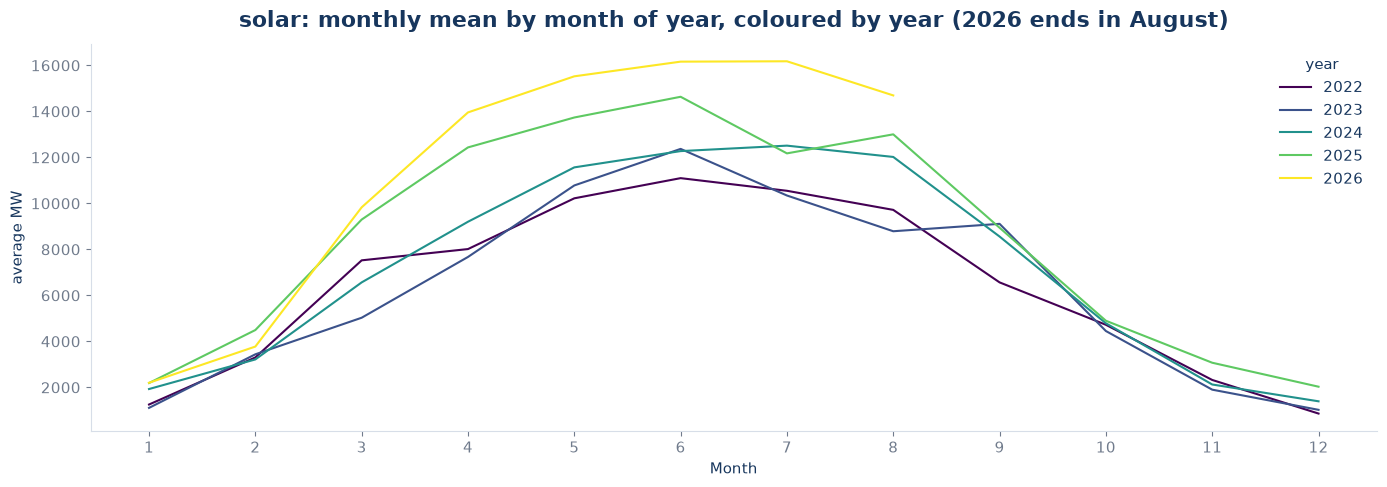

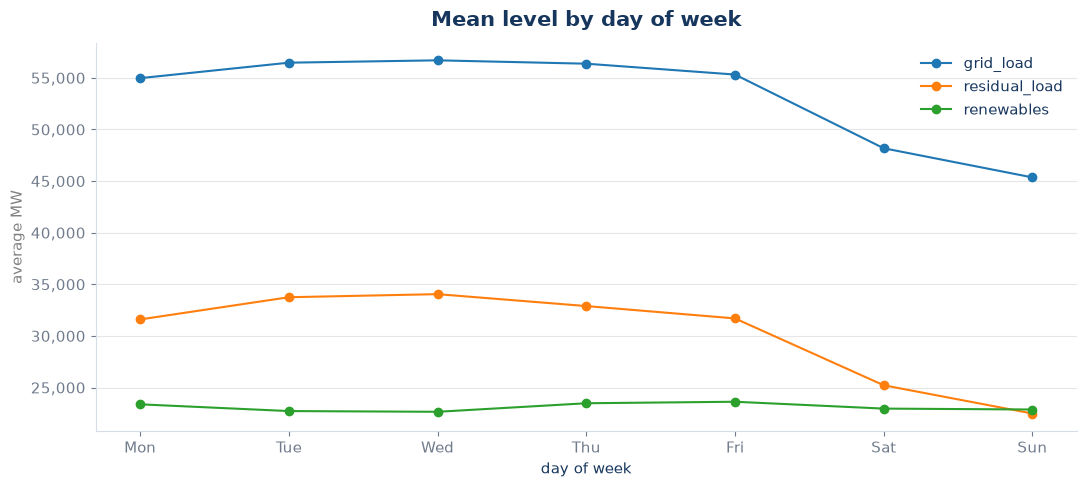

,weekday,weekend,delta_%
grid_load,55966.0,46769.0,-16.0
residual_load,32797.0,23853.0,-27.0
renewables,23169.0,22916.0,-1.0


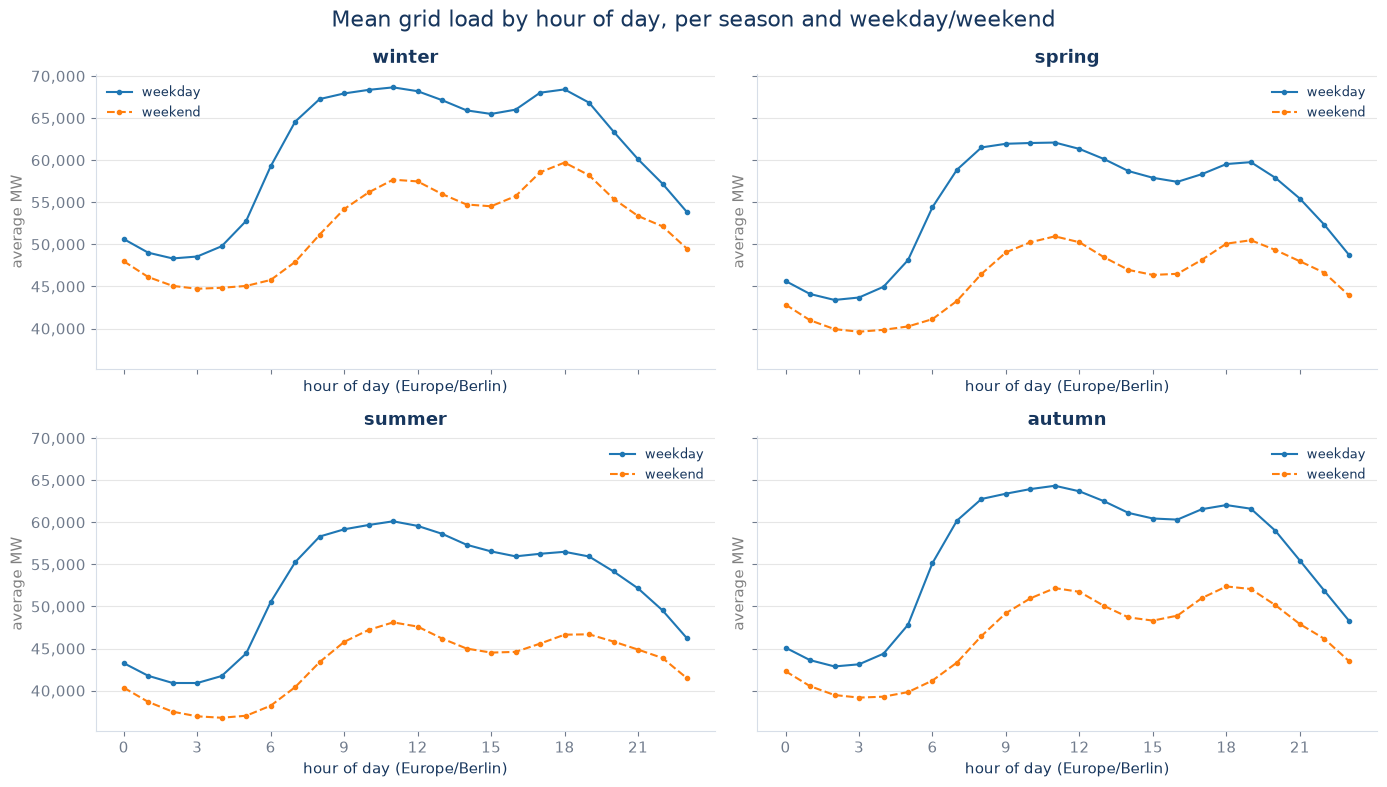

45 federal holidays across 2022-2026, 42 of them inside the record
distinct holiday names: ['Ascension Day', 'Christmas Day', 'Easter Monday', 'German Unity Day', 'Good Friday', 'Labor Day', "New Year's Day", 'Pentecost Monday', 'Second Day of Christmas']


,n,mean_delta_pct
holiday,,
Christmas Day,4,-23.7
Second Day of Christmas,4,-23.3
New Year's Day,5,-23.2
Easter Monday,5,-23.1
Pentecost Monday,5,-22.7
Ascension Day,5,-19.2
Labor Day,5,-19.0
German Unity Day,4,-18.2
Good Friday,5,-16.9


,xmas_period,dec_baseline,delta_%
date,,,
2022,46259.0,61166.0,-24.0
2023,45940.0,61512.0,-25.0
2024,47594.0,61225.0,-22.0
2025,51085.0,62077.0,-18.0
2026,48758.0,NaN,NaN


lowest-load days in the record:


,grid_load,dow,is_holiday
date,,,
2023-05-28,37536.0,6,False
2024-03-31,37596.0,6,False
2023-05-29,38536.0,0,True
2023-04-09,38760.0,6,False
2026-08-23,39152.0,6,False
2026-05-24,39189.0,6,False
2024-09-22,39405.0,6,False
2023-06-04,39551.0,6,False


,grid_load,residual_load,hours,load_vs_2022_%
year,,,,
2022,55733.2,34040.5,6047,0.0
2023,51637.6,29698.5,6047,-7.3
2024,52481.7,28821.3,6071,-5.8
2025,52234.6,29030.9,6047,-6.3
2026,53024.3,26256.6,6047,-4.9


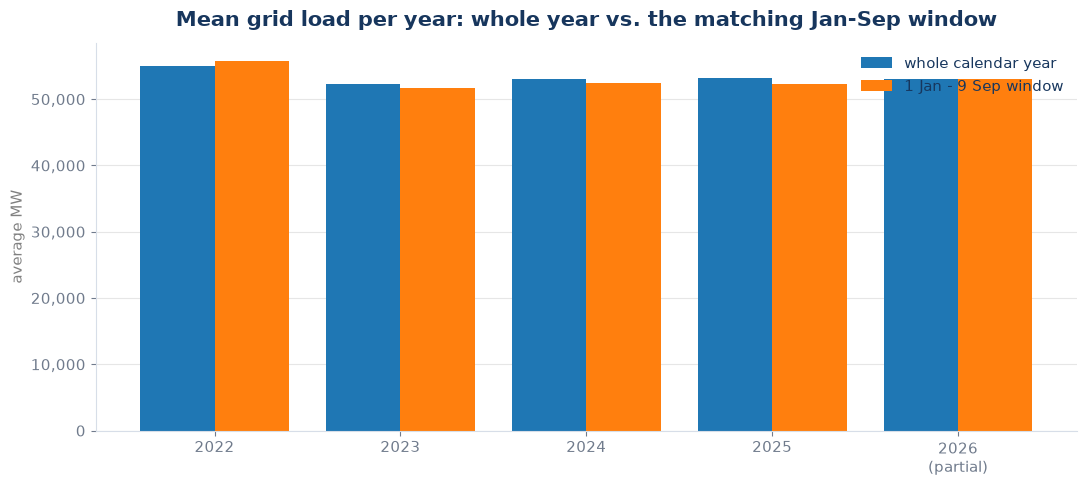

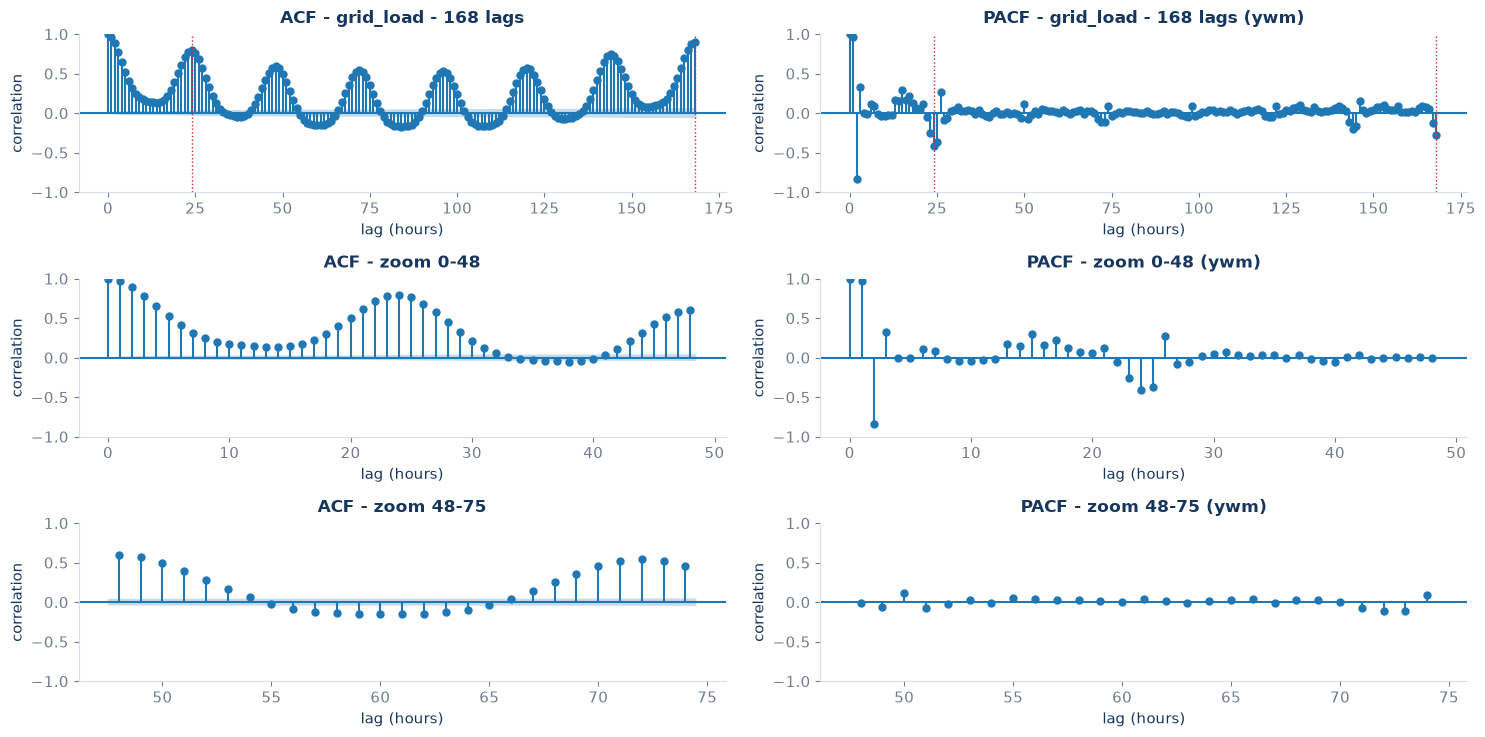

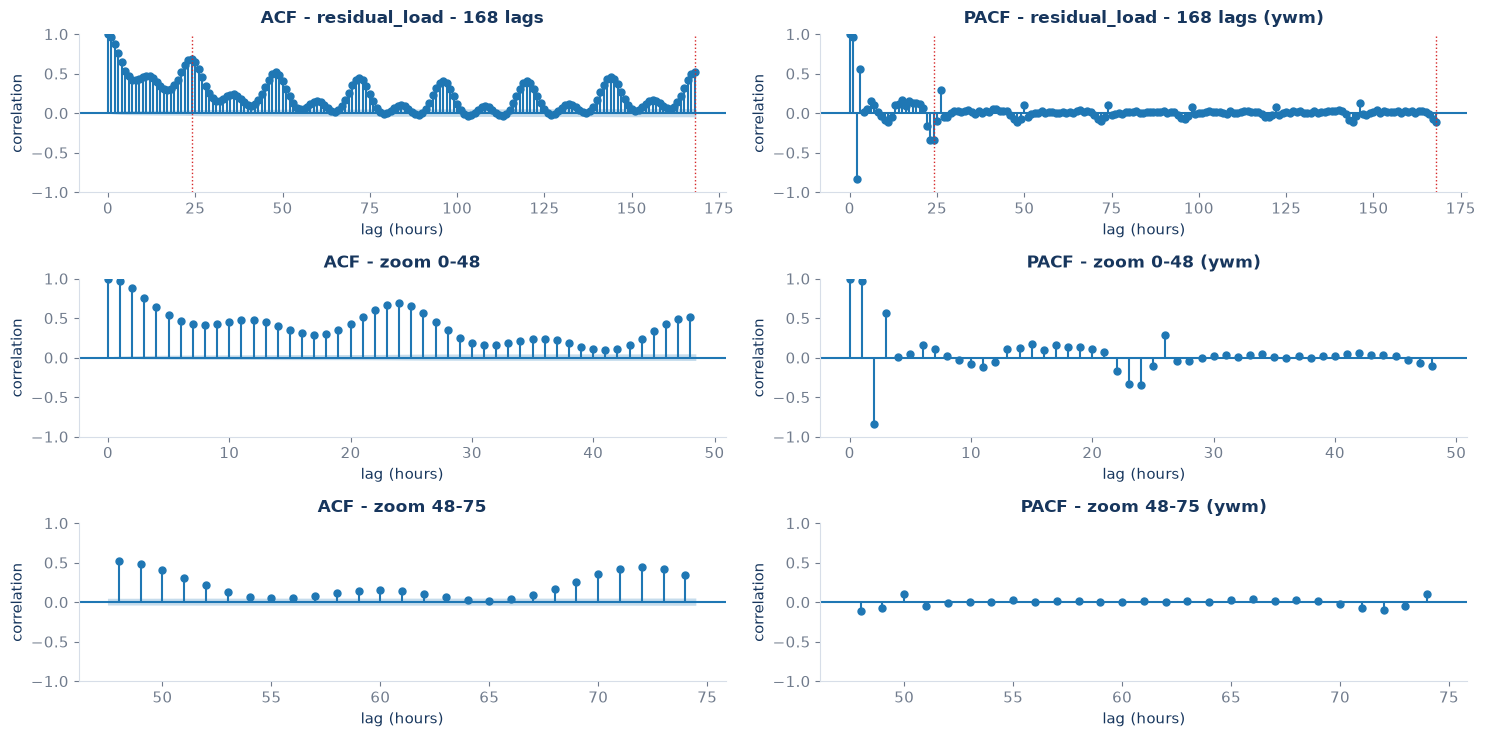

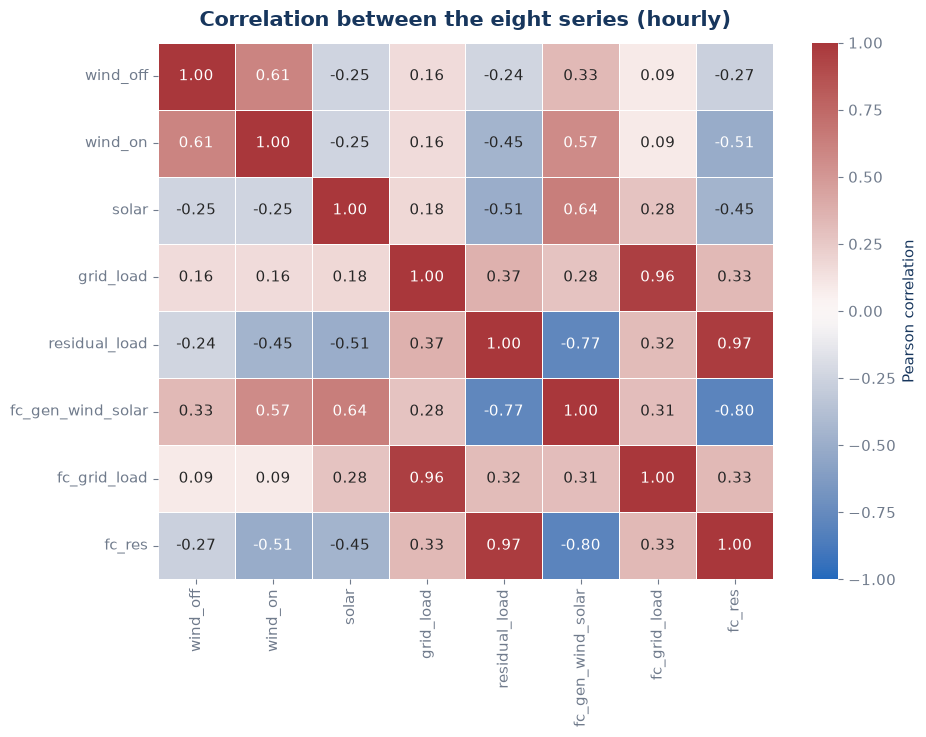

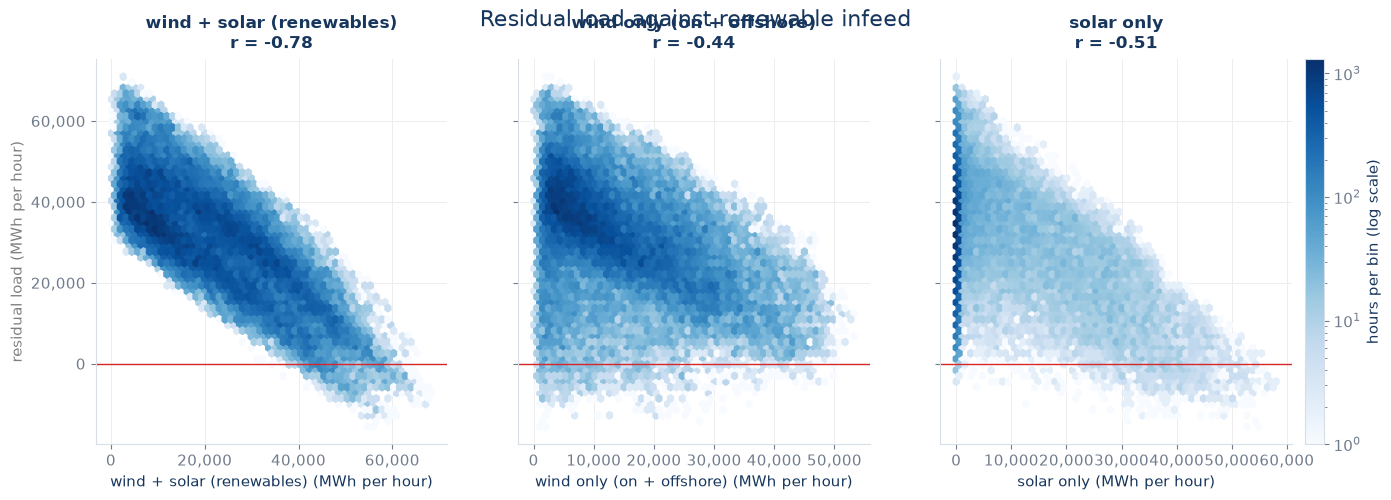

,residual_load,grid_load
lag 1 h,0.966,0.969
lag 24 h,0.688,0.798
lag 48 h,0.516,0.598
lag 168 h,0.524,0.908


,residual_load
mean,30239.64
median,31152.16
std,14339.75
skew,-0.18
excess kurtosis,-0.28
min,-15561.59
max,70964.00
range,86525.59
min in std below median,3.26
max in std above median,2.78


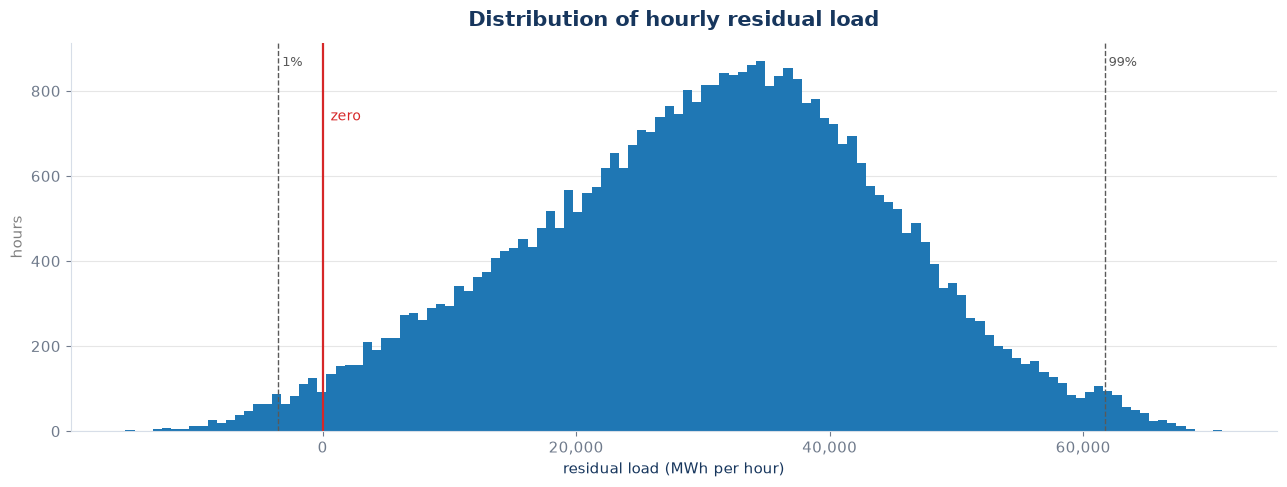

negative hours overall : 854 of 41,107  (2.08%)


,negative_hours,hours,share_%,note
year,,,,
2022,0,8759,0.00,
2023,51,8759,0.58,
2024,75,8783,0.85,
2025,202,8759,2.31,
2026,526,6047,8.70,"partial year, to 09-09"


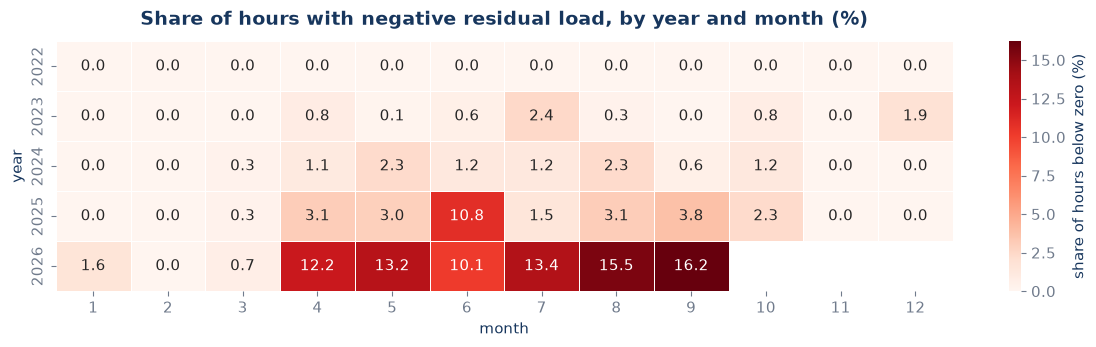

411 hours in each tail (1 % of the record by rank)
  low  tail spans    -15,562 ..     -3,503 MWh
  high tail spans     61,693 ..     70,964 MWh


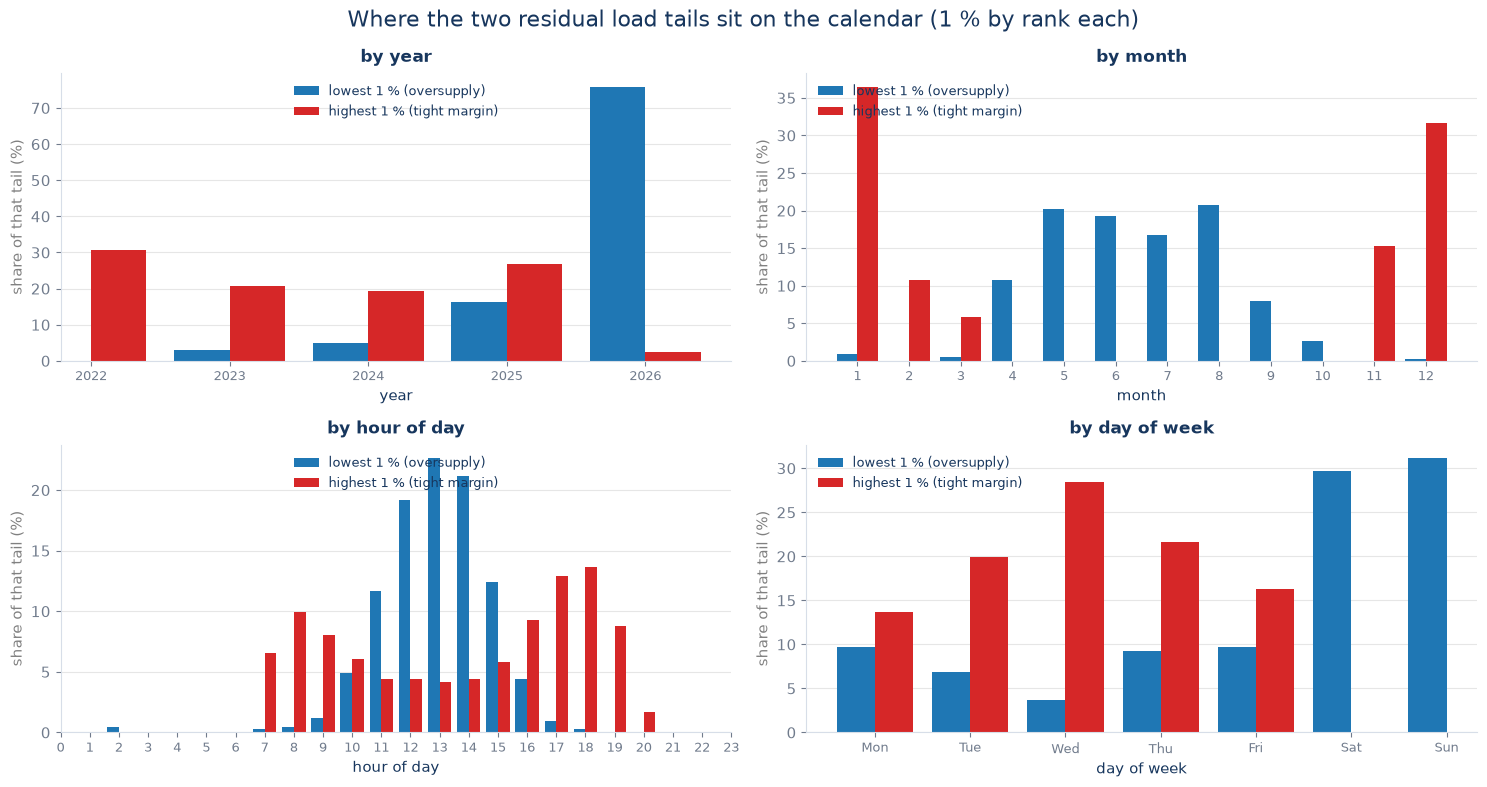

longest negative runs (top 5), showing the tie the rule has to break:


,start,length
0,2026-08-30 05:00:00,12
1,2026-06-13 08:00:00,11
2,2026-06-14 08:00:00,11
3,2025-10-26 04:00:00,10
4,2026-01-01 06:00:00,9



highest 24 h rolling mean: 61,086 MW over 2022-01-10 06:00:00 .. 2022-01-11 05:00:00


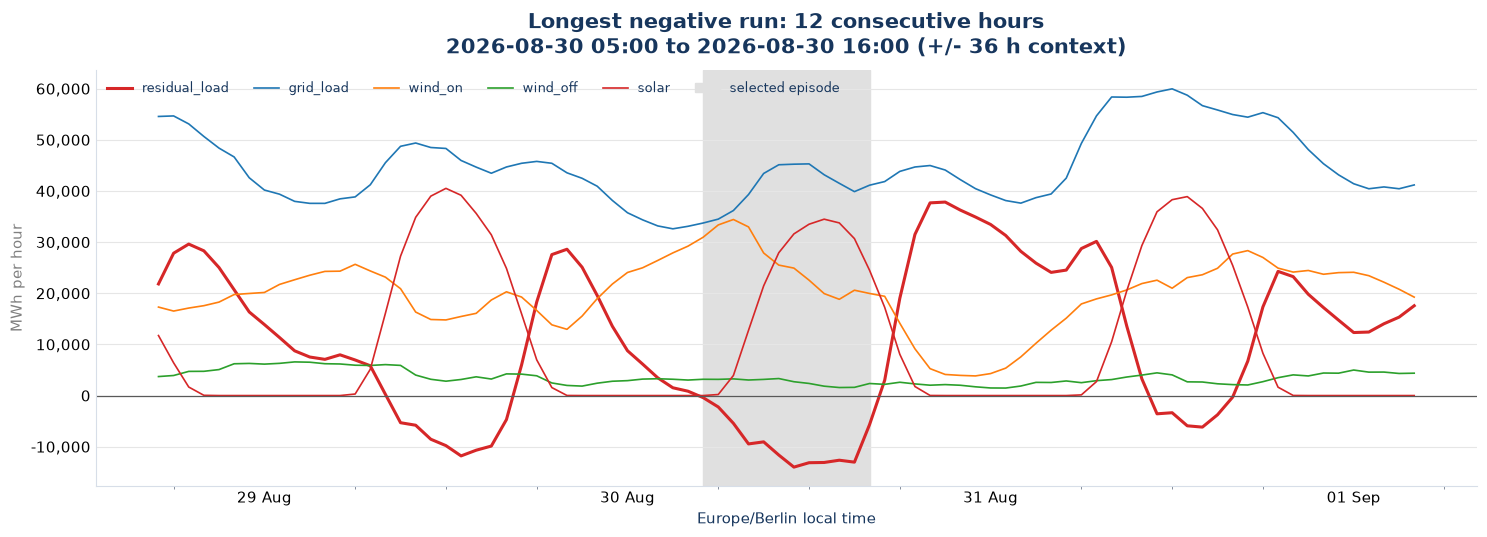

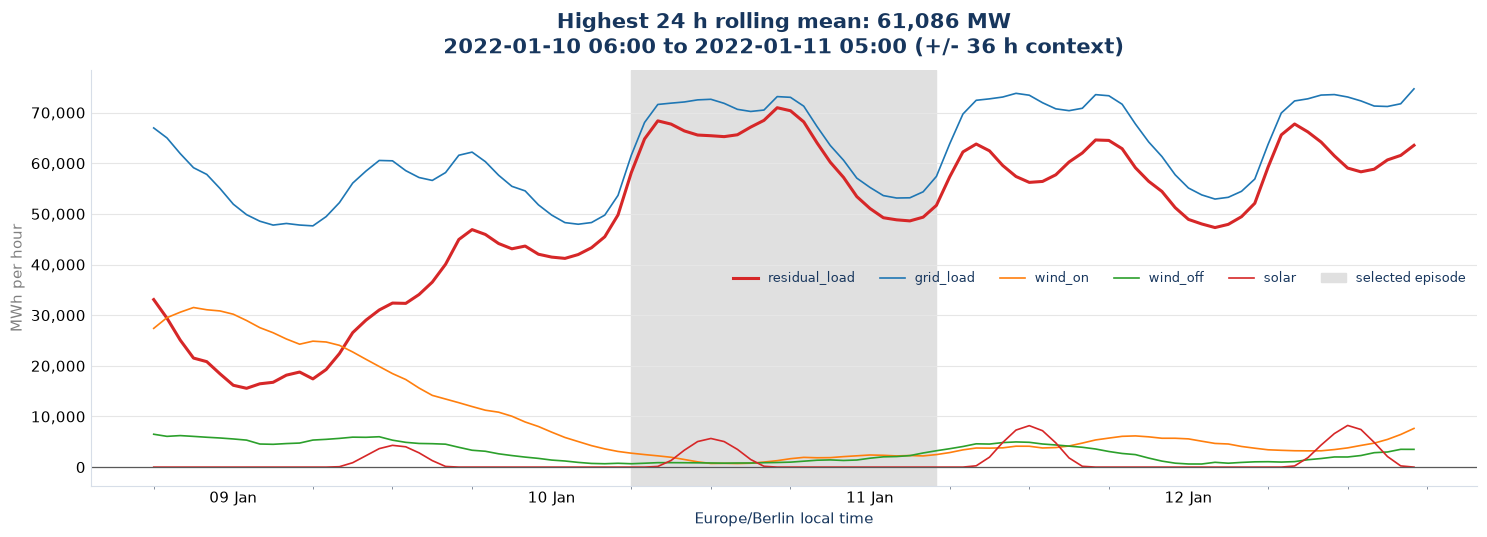

self-check passed
  41,107 rows, 2022-01-01 00:00:00 .. 2026-09-09 23:00:00
  5 index gaps, 0 NaNs across 8 data columns
  18 columns, exactly SERIES + DERIVED -- no flag column was created


In [16]:
with open("EDA-simple-draft.ipynb", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

for cell in nb.cells:
    if (
        cell.cell_type == "code"
    ):
        exec(cell.source, globals())